Modelos de Machine Learning

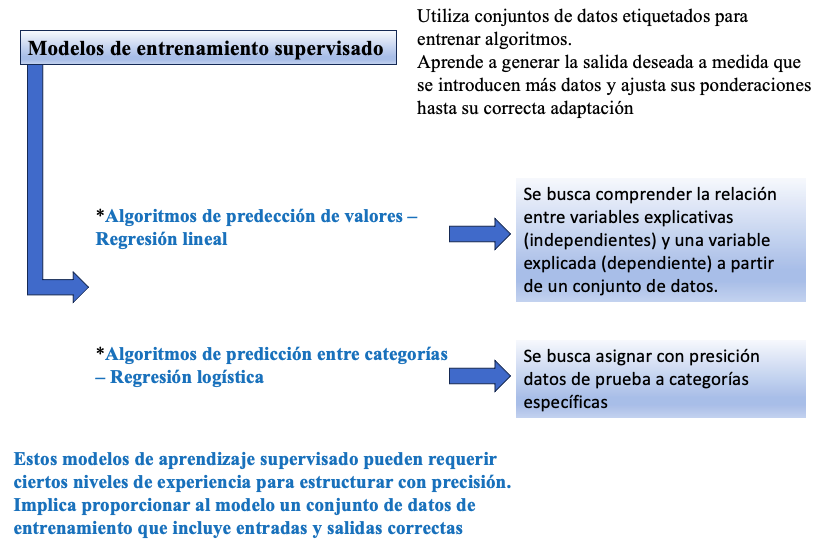

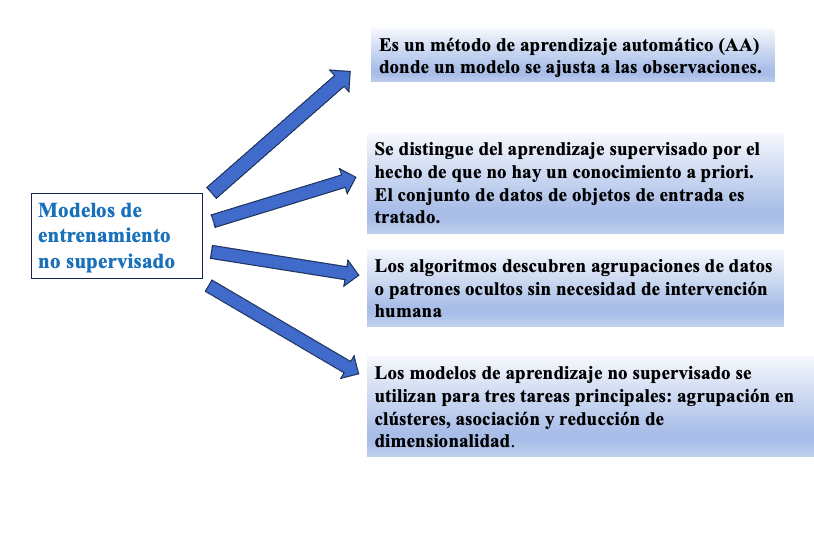

Entrenamiento Supervisado

Algoritmos de predicción de valores - Regresión lineal

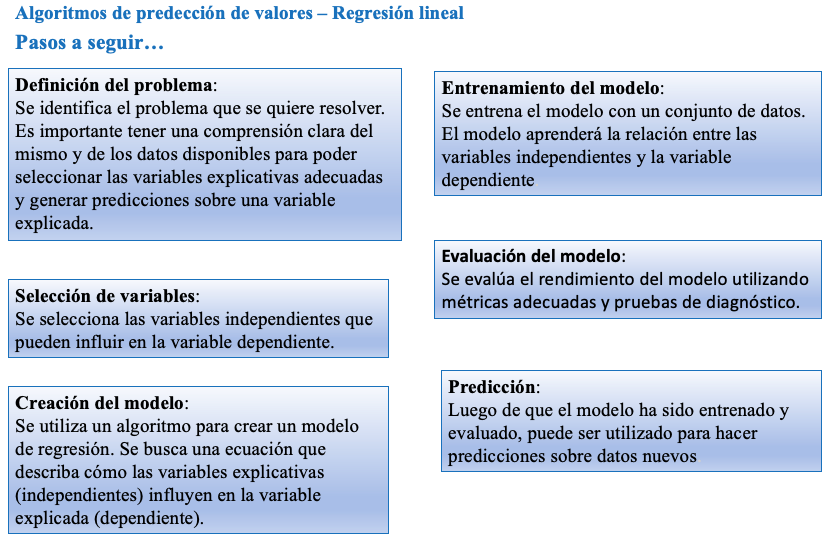

Modelo de regrsión lineal

In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm #para ajustar el modelo y hacer pruebas estadíticas
import matplotlib.pyplot as plt
import seaborn as sns


# Descargar datos financieros de Yahoo Finance
# Armamos una función para descargar datos de Yahoo Finance
def descargar_datos(ticker, inicio, fin):
    """
    Descarga datos históricos de Yahoo Finance
    """
    datos = yf.download(ticker, start=inicio, end=fin)
    return datos

# Ejemplo: Datos de Apple (AAPL) y del S&P 500 (^GSPC) como variable explicativa
inicio = '2023-01-01'
fin = '2025-12-31'

# Descargar datos
print("Descargando datos de AAPL y S&P 500...")
aapl = descargar_datos('AAPL', inicio, fin)
sp500 = descargar_datos('^GSPC', inicio, fin)

# Prepararamos los datos

datos = pd.DataFrame({
    'AAPL_Close': aapl['Close'].squeeze(),  # Convert to Series
    'SP500_Close': sp500['Close'].squeeze() # Convert to Series
}, index=aapl.index).dropna()

# Calculamos los retornos diarios y lo agregamos al dataframe
datos['AAPL_Retorno'] = datos['AAPL_Close'].pct_change() * 100
datos['SP500_Retorno'] = datos['SP500_Close'].pct_change() * 100
datos = datos.dropna()

datos #visualizamos el dataframe

Descargando datos de AAPL y S&P 500...


/tmp/ipython-input-2968875869.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start=inicio, end=fin)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2968875869.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start=inicio, end=fin)
[*********************100%***********************]  1 of 1 completed


,AAPL_Close,SP500_Close,AAPL_Retorno,SP500_Retorno
Date,,,,
2023-01-04,124.744118,3852.969971,1.031418,0.753897
2023-01-05,123.421249,3808.100098,-1.060466,-1.164553
2023-01-06,127.962448,3895.080078,3.679430,2.284078
2023-01-09,128.485641,3892.090088,0.408865,-0.076763
2023-01-10,129.058243,3919.250000,0.445654,0.697823
...,...,...,...,...
2025-07-25,213.880005,6388.640137,0.056143,0.397433
2025-07-28,214.050003,6389.770020,0.079483,0.017686
2025-07-29,211.270004,6370.859863,-1.298761,-0.295944


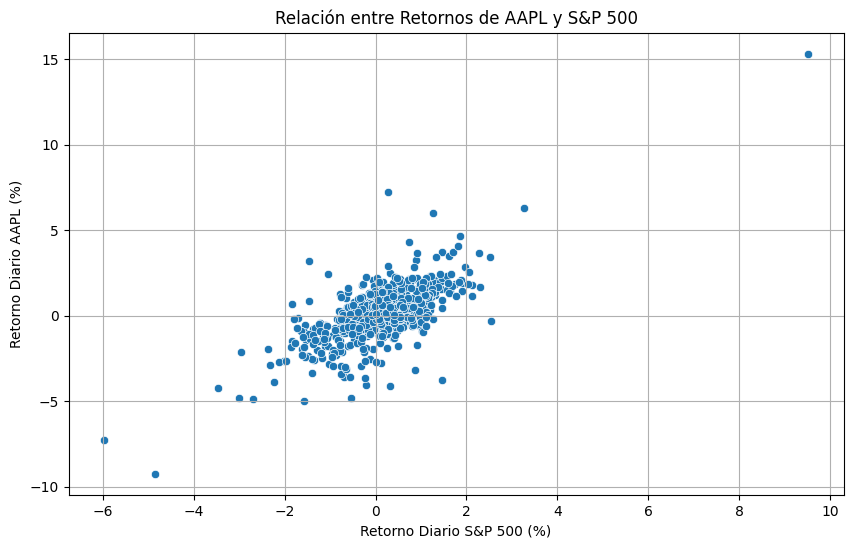

In [ ]:
# Visualizamos la relación entre los retornos
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SP500_Retorno', y='AAPL_Retorno', data=datos)
plt.title('Relación entre Retornos de AAPL y S&P 500')
plt.xlabel('Retorno Diario S&P 500 (%)')
plt.ylabel('Retorno Diario AAPL (%)')
plt.grid(True)
plt.show()

In [ ]:
# Preparar datos para el modelo
X = datos[['SP500_Retorno']]  # Variable independiente (retorno del mercado)
y = datos['AAPL_Retorno']     # Variable dependiente (retorno de AAPL)

In [ ]:
# Dividimos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creamos y entrenamos el modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predecimos con el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluamos el modelo y sus métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nResultados del Modelo de Regresión Lineal:")
print(f"Coeficiente (Beta1): {modelo.coef_[0]:.4f}")
print(f"Intercepto (Beta0): {modelo.intercept_:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")


Resultados del Modelo de Regresión Lineal:
Coeficiente (Beta1): 1.2077
Intercepto (Beta0): -0.0269
Error Cuadrático Medio (MSE): 1.4700
Coeficiente de Determinación (R²): 0.4036


b0+b1*retorno del mercado=retorno apple

In [ ]:
# Ajustamos un modelo OLS con statsmodels para obtener los valores p y la estadística t
import statsmodels.api as sm #para ajustar el modelo y hacer pruebas estadíticas
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:           AAPL_Retorno   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     574.7
Date:                Thu, 31 Jul 2025   Prob (F-statistic):           8.22e-86
Time:                        20:47:04   Log-Likelihood:                -799.03
No. Observations:                 516   AIC:                             1602.
Df Residuals:                     514   BIC:                             1611.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0269      0.050     -0.535

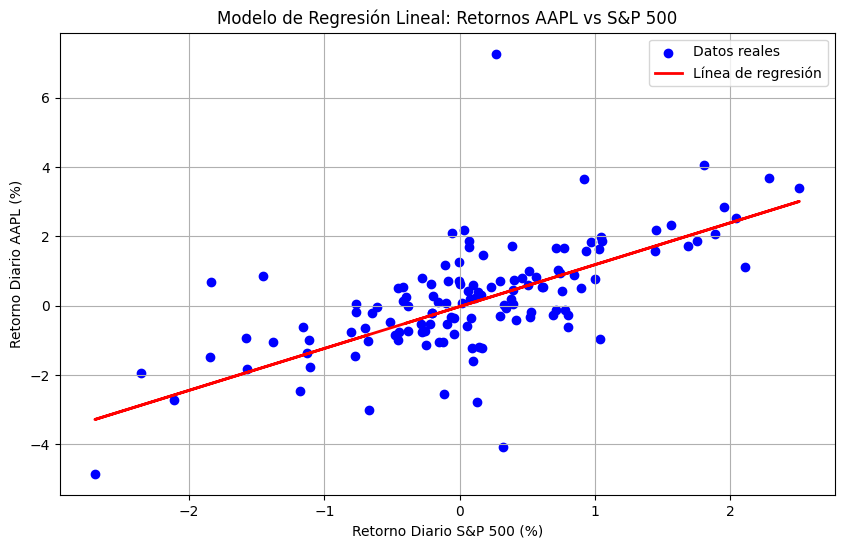

In [ ]:
# Visualizamos resultados
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Línea de regresión')
plt.title('Modelo de Regresión Lineal: Retornos AAPL vs S&P 500')
plt.xlabel('Retorno Diario S&P 500 (%)')
plt.ylabel('Retorno Diario AAPL (%)')
plt.legend()
plt.grid(True)
plt.show()

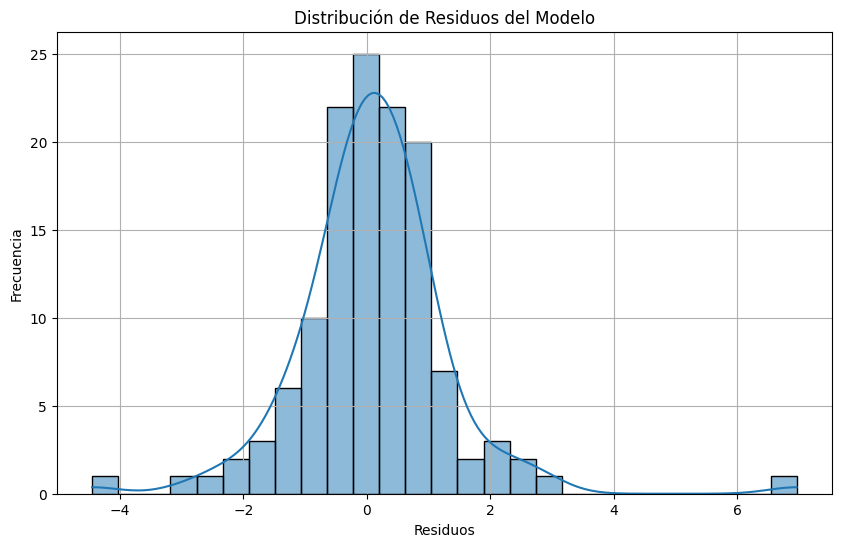

In [ ]:
# Análisis de residuos
residuos = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuos, kde=True)
plt.title('Distribución de Residuos del Modelo')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

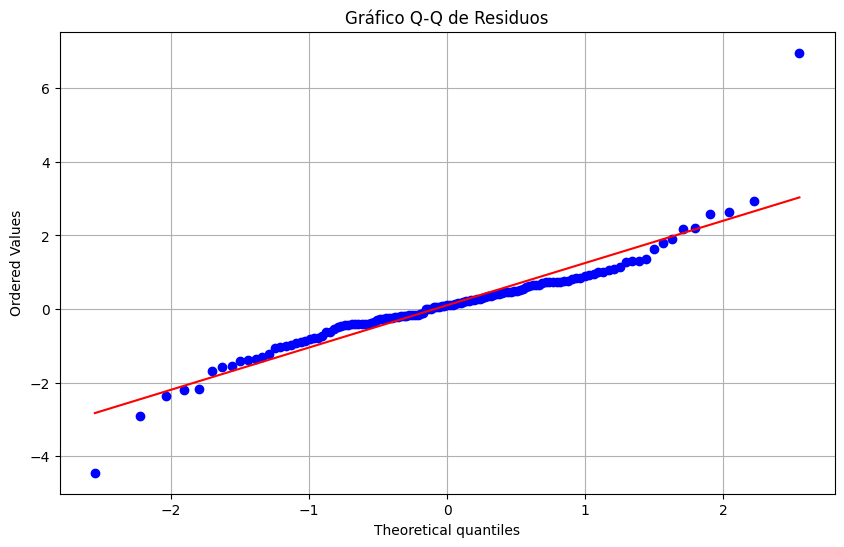

In [ ]:
# Gráfico Q-Q para normalidad de residuos
import scipy.stats as stats
plt.figure(figsize=(10, 6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de Residuos')
plt.grid(True)
plt.show()

Regresión Lineal Múltiple

In [ ]:
#Paso 1
# Importar librerías necesarias
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm #para ajustar el modelo y hacer pruebas estadíticas


In [ ]:
#Paso 2
# Descargamos datos financieros para lo cual armamos una función
def descargar_datos(tickers, inicio, fin):
    """
    Descarga datos históricos de múltiples activos
    """
    datos = yf.download(tickers, start=inicio, end=fin)['Close']
    return datos

# Definir período de tiempo y activos
inicio = '2023-01-01'
fin = '2025-12-31'
activos = ['AAPL', '^GSPC', '^TNX', 'DX-Y.NYB']  # Apple, S&P 500, Yield 10y, Dólar Index

# Descargar datos
print("Descargando datos financieros...")
datos = descargar_datos(activos, inicio, fin)
datos.columns = ['AAPL', 'SP500', 'Yield_10y', 'Dolar_Index']  # Renombrar columnas

# Calcular retornos diarios y limpiar datos
retornos = datos.pct_change().dropna()
retornos *= 100  # Convertir a porcentaje
retornos #visualizamos el dataframe que vamos a usar

Descargando datos financieros...


/tmp/ipython-input-382567996.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(tickers, start=inicio, end=fin)['Close']
[*********************100%***********************]  4 of 4 completed
/tmp/ipython-input-382567996.py:21: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = datos.pct_change().dropna()


,AAPL,SP500,Yield_10y,Dolar_Index
Date,,,,
2023-01-04,1.031437,-0.258321,0.753897,-2.214602
2023-01-05,-1.060478,0.757795,-1.164553,0.296574
2023-01-06,3.679405,-1.104345,2.284078,-4.059140
2023-01-09,0.408913,-0.847129,-0.076763,-1.456992
2023-01-10,0.445618,0.233008,0.697823,2.957068
...,...,...,...,...
2025-07-25,0.056143,0.277269,0.397433,-0.499089
2025-07-28,0.079483,1.034308,0.017686,0.775192
2025-07-29,-1.298761,0.253395,-0.295944,-2.036203


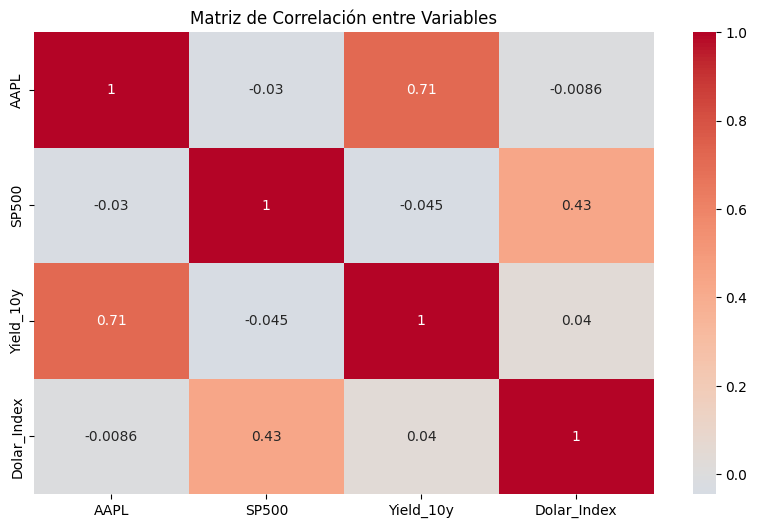

In [ ]:
# Visualizamos las correlaciones
plt.figure(figsize=(10, 6))
sns.heatmap(retornos.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación entre Variables')
plt.show()

In [ ]:
# Preparamos las variables para el modelo
X = retornos[['SP500', 'Yield_10y', 'Dolar_Index']]  # Variables independientes
y = retornos['AAPL']  # Variable dependiente

# Estandarizamos variables (importante para regresión múltiple)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
# Calcular VIF para detectar multicolinealidad
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("\nFactores de Inflación de Varianza (VIF):")
print(vif_data)


Factores de Inflación de Varianza (VIF):
      Variable       VIF
0        SP500  1.235064
1    Yield_10y  1.006806
2  Dolar_Index  1.234667


In [ ]:
# Dividimos datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Creamos y entrenamos modelo de regresión múltiple
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predecimos con el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluamos el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Mostrar resultados
print("\nResultados del Modelo de Regresión Múltiple:")
print(f"Intercepto (Beta0): {modelo.intercept_:.4f}")
for i, col in enumerate(X.columns):
    print(f"Coeficiente para {col}: {modelo.coef_[i]:.4f}")
print(f"\nError Cuadrático Medio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")


Resultados del Modelo de Regresión Múltiple:
Intercepto (Beta0): 0.0637
Coeficiente para SP500: 0.0161
Coeficiente para Yield_10y: 1.0776
Coeficiente para Dolar_Index: -0.0560

Error Cuadrático Medio (MSE): 1.5380
Coeficiente de Determinación (R²): 0.6183


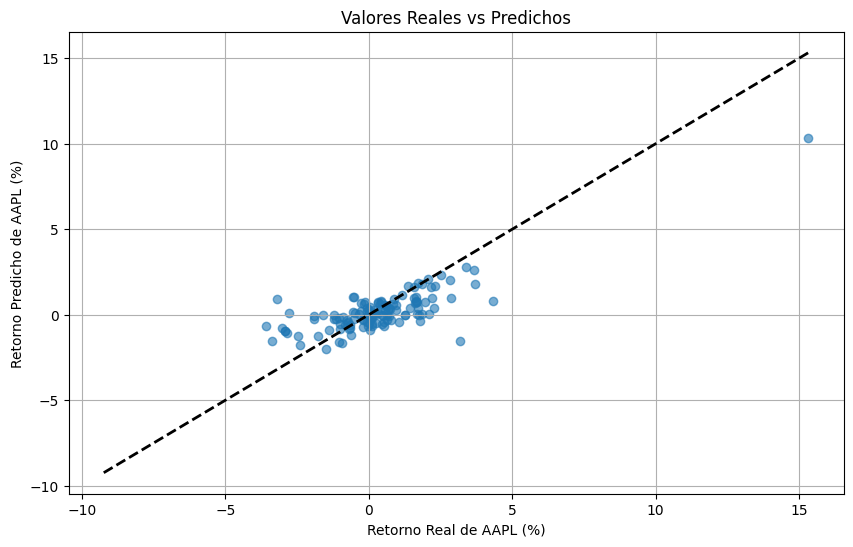

In [ ]:
# Gráfico de valores reales vs predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Retorno Real de AAPL (%)')
plt.ylabel('Retorno Predicho de AAPL (%)')
plt.title('Valores Reales vs Predichos')
plt.grid(True)
plt.show()

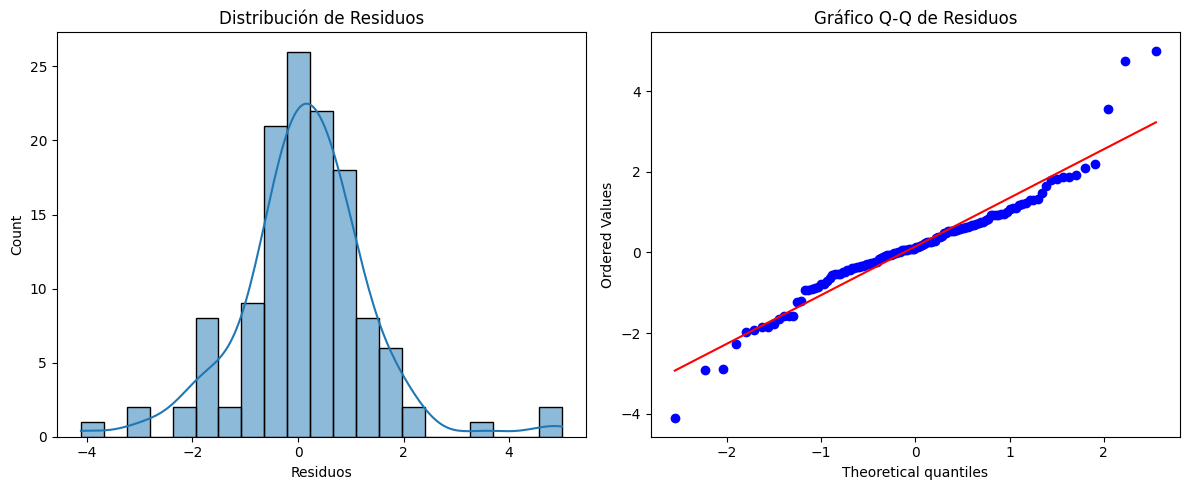

In [ ]:
# Análisis de residuos
import scipy.stats as stats
residuos = y_test - y_pred
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuos, kde=True)
plt.title('Distribución de Residuos')
plt.xlabel('Residuos')

plt.subplot(1, 2, 2)
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de Residuos')

plt.tight_layout()
plt.show()

In [ ]:
# Ajustamos un modelo OLS con statsmodels para obtener los valores p y la estadística t
import statsmodels.api as sm
import pandas as pd

# Reseteamos los indices de  y_train and X_train
y_train = y_train.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)


if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train)

X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.450
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     139.8
Date:                Thu, 31 Jul 2025   Prob (F-statistic):           3.26e-66
Time:                        20:50:31   Log-Likelihood:                -797.08
No. Observations:                 517   AIC:                             1602.
Df Residuals:                     513   BIC:                             1619.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0637      0.050      1.275      

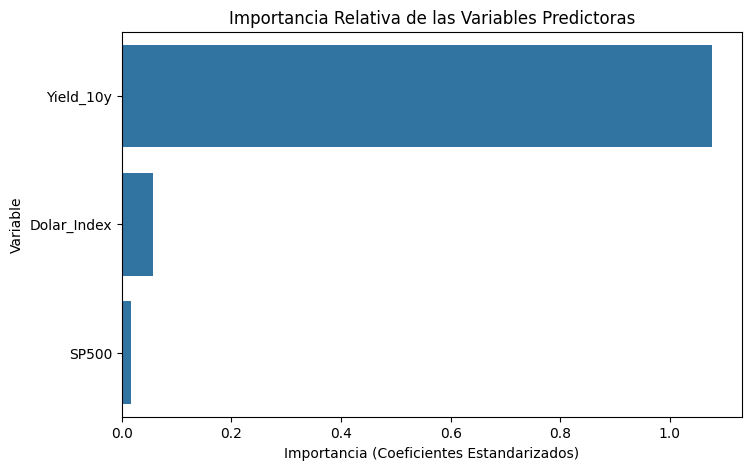

In [ ]:
# Importancia de variables (usando valores absolutos de coeficientes estandarizados)
importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': np.abs(modelo.coef_)
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importancia', y='Variable', data=importancia)
plt.title('Importancia Relativa de las Variables Predictoras')
plt.xlabel('Importancia (Coeficientes Estandarizados)')
plt.show()

Entrenamiento Supervisado

Predicción de categorías - Regresión logística

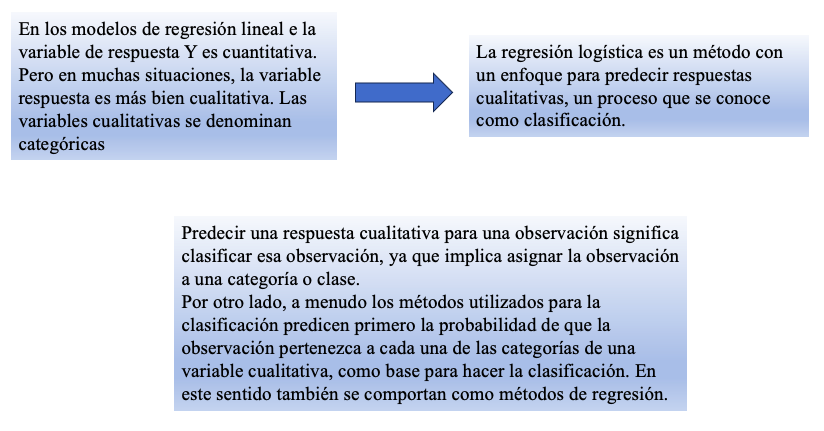

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import seaborn as sns  # Para visualizar la matriz de confusión

In [ ]:
# Cargar los datos
# Cargar el dataset
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Carseats.csv'
data = pd.read_csv(url)
data

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [ ]:
# Crear una nueva variable binaria para ventas altas/bajas
data['Ventas Altas'] = (data['Sales'] > data['Sales'].median()).astype(int)
data

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Ventas Altas
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes,1
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes,0
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes,0
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes,0


In [ ]:
# Seleccionar las variables predictoras y la variable objetivo
X = data[['Price', 'Advertising', 'Income', 'Population']]
y = data['Ventas Altas']

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Ajustar el modelo de regresión logística
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Predecir las etiquetas para el conjunto de prueba
y_pred = model.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1])

In [ ]:
# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.775

In [ ]:
# Calcular e imprimir la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print('Matriz de confusión:\n', conf_matrix)

Matriz de confusión:
 [[30  7]
 [11 32]]


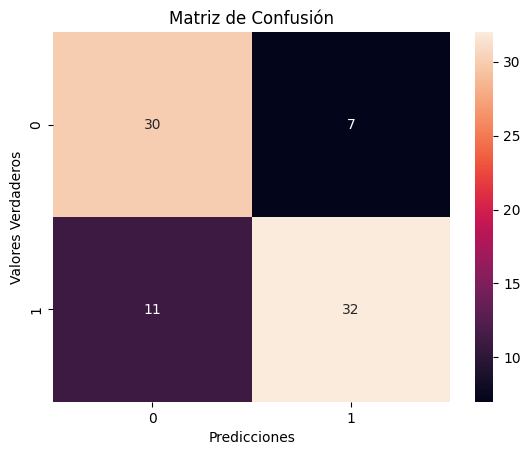

In [ ]:
# Visualizar la matriz de confusión usando Seaborn
sns.heatmap(conf_matrix, annot=True, fmt='g')
plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.show()

In [ ]:
# Imprimir el informe de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.81      0.77        37
           1       0.82      0.74      0.78        43

    accuracy                           0.78        80
   macro avg       0.78      0.78      0.77        80
weighted avg       0.78      0.78      0.78        80



In [ ]:
#ver probabilidades predichas
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Obtener los coeficientes del modelo
coefficients = model.coef_[0]
intercept = model.intercept_[0]

print('Coefficients:')
for feature, coef in zip(X.columns, coefficients):
    print(f'{feature}: {coef}')
print(f'Intercept: {intercept}')

# Mostrar las probabilidades predichas
print('Predicted Probabilities:')
print(y_pred_prob)


Coefficients:
Price: -0.042755165507800404
Advertising: 0.09975422438836605
Income: 0.003172719722761881
Population: 0.0003070100514035633
Intercept: 3.947234726002689
Predicted Probabilities:
[0.79629205 0.30373153 0.49731602 0.29474308 0.40527067 0.24400283
 0.79315931 0.76914063 0.68050081 0.21323608 0.27774594 0.65333715
 0.65306572 0.32366845 0.34922971 0.95881814 0.12885001 0.90001481
 0.26654648 0.49291445 0.82889942 0.21644147 0.24241567 0.39569673
 0.55731068 0.31007033 0.64433305 0.65636056 0.51763481 0.18190584
 0.64000184 0.68673661 0.37568928 0.31872271 0.6718734  0.22697764
 0.45251415 0.65748484 0.40178817 0.19484704 0.48614035 0.13436786
 0.91166752 0.64494033 0.22555155 0.70155932 0.57332476 0.58518714
 0.25808922 0.33751527 0.93347828 0.63016709 0.43916733 0.82354298
 0.44451779 0.15207666 0.43244911 0.71143241 0.64049061 0.23626553
 0.31663077 0.57286402 0.83200139 0.12373297 0.31529314 0.54992875
 0.63248043 0.41557874 0.54883888 0.69005214 0.25352293 0.42672288
 0.

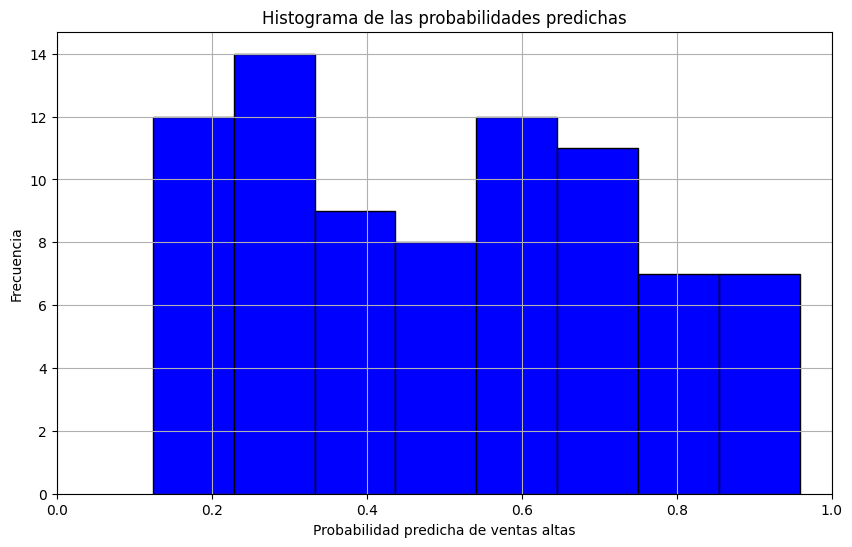

In [ ]:
# Crear un gráfico de las probabilidades predichas
# Obtener las probabilidades predichas
logit = LogisticRegression()
logit.fit(X_train, y_train)
prob = logit.predict_proba(X_test)
#armamos el gráfico

plt.figure(figsize=(10,6))
plt.hist(prob[:,1], bins=8, color='blue', edgecolor='black')
plt.xlim(0,1)
plt.title('Histograma de las probabilidades predichas')
plt.xlabel('Probabilidad predicha de ventas altas')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

Otro ejemplo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Cargar los datos importando un dataset desde el ordenador
smarket = pd.read_csv('Smarket.csv', index_col=0, parse_dates=True)
# Crear una variable binaria para la dirección
smarket['Direction2'] = np.where(smarket['Direction'] == 'Up', 1, 0)

smarket #visualizamos el data frame

,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction,Direction2
Year,,,,,,,,,
2001-01-01,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up,1
2001-01-01,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up,1
2001-01-01,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down,0
2001-01-01,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up,1
2001-01-01,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up,1
...,...,...,...,...,...,...,...,...,...
2005-01-01,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up,1
2005-01-01,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down,0
2005-01-01,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up,1


In [ ]:
# Dividimos los datos en conjuntos de entrenamiento y prueba tanto para las variables independientes como la dependiente
X_train = smarket[:'2004'][['Lag1','Lag2']]
y_train = smarket[:'2004']['Direction2']
X_test = smarket['2005':][['Lag1','Lag2']]
y_test = smarket['2005':]['Direction2']

In [ ]:
# Ajustar el modelo de regresión logística
logit = LogisticRegression()
logit.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Obtenemos las probabilidades predichas
prob = logit.predict_proba(X_test)

In [ ]:
# Creamos las predicciones del modelo
pred = np.where(prob[:,1] > 0.5, 1, 0)

In [ ]:
# Calculamos la tasa de aciertos e imprimimos la matriz de confusión
print('Tasa de aciertos:', np.mean(pred == y_test))
print('Matriz de confusión:\n', confusion_matrix(y_test, pred))

Tasa de aciertos: 0.5595238095238095
Matriz de confusión:
 [[ 35  76]
 [ 35 106]]


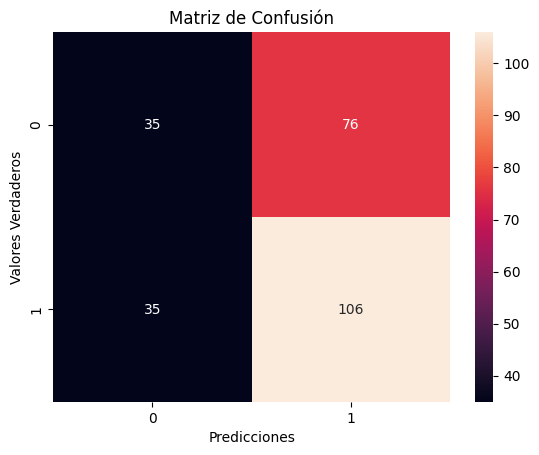

In [ ]:
# Visualizamos la matriz de confusión usando Seaborn
conf_matrix2= confusion_matrix(y_test, pred)
sns.heatmap(conf_matrix2, annot=True, fmt='g')
plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.show()

In [ ]:
# Imprimir el informe de clasificación
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.50      0.32      0.39       111
           1       0.58      0.75      0.66       141

    accuracy                           0.56       252
   macro avg       0.54      0.53      0.52       252
weighted avg       0.55      0.56      0.54       252



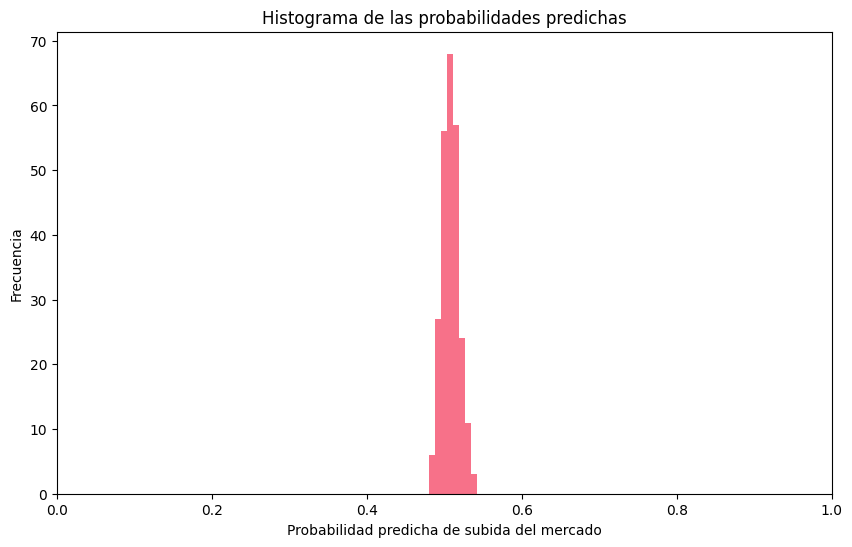

In [ ]:
# Creamos un gráfico de las probabilidades predichas
plt.figure(figsize=(10,6))
plt.hist(prob[:,1], bins=8)
plt.xlim(0,1)
plt.title('Histograma de las probabilidades predichas')
plt.xlabel('Probabilidad predicha de subida del mercado')
plt.ylabel('Frecuencia')
plt.show()


Entrenamiento no supervisado

PCA

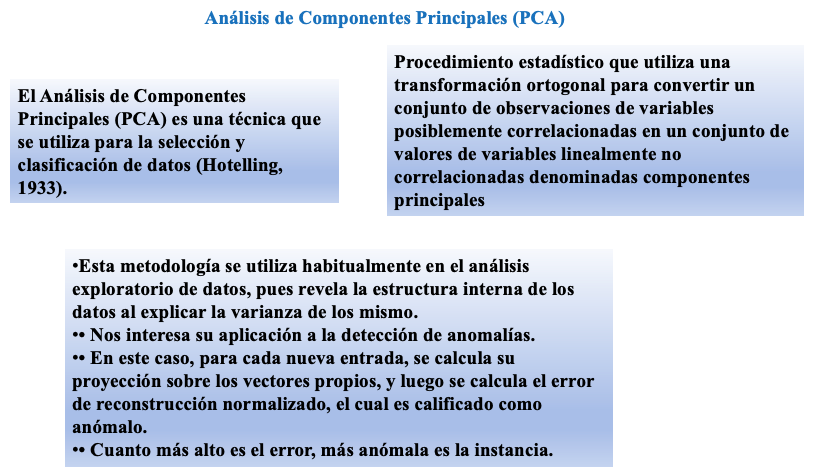

In [ ]:
#paso 1 - importar módulos de las librerías a utilizar
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

In [ ]:
#paso 2 - importar librerías para realizar gráficos
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use("ggplot") or plt.style.use("ggplot")

In [ ]:
#paso 3 - importar laibrerías para el preprocesado y modelado de datos
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

In [ ]:
# Seleccionar las variables numéricas
features = ['Price', 'Advertising', 'Income', 'Population', 'Age', 'Education']
X = data[features]
X

,Price,Advertising,Income,Population,Age,Education
0,120,11,73,276,42,17
1,83,16,48,260,65,10
2,80,10,35,269,59,12
3,97,4,100,466,55,14
4,128,3,64,340,38,13
...,...,...,...,...,...,...
395,128,17,108,203,33,14
396,120,3,23,37,55,11
397,159,12,26,368,40,18
398,95,7,79,284,50,12


In [ ]:
y=data['Sales']
y

,Sales
0,9.50
1,11.22
2,10.06
3,7.40
4,4.15
...,...
395,12.57
396,6.14
397,7.41
398,5.94


In [ ]:
# Preprocesamiento de datos - Hacemos el escalamiento

x_scaled = StandardScaler().fit_transform(X)
x_scaled

array([[ 0.17782345,  0.65717702,  0.15536099,  0.07581929, -0.69978222,
         1.18444912],
       [-1.38685375,  1.40995711, -0.73906037, -0.0328822 ,  0.72172284,
        -1.4901134 ],
       [-1.51371947,  0.506621  , -1.20415947,  0.02826239,  0.35089544,
        -0.72595268],
       ...,
       [ 1.82707779,  0.80773304, -1.52615116,  0.70085283, -0.82339136,
         1.56652948],
       [-0.87939087,  0.05495295,  0.37002211,  0.13017003, -0.20534568,
        -0.72595268],
       [ 0.17782345, -0.99893918, -1.13260576, -1.61584759, -0.26715025,
         0.80236876]])

In [ ]:
# Aplicamos el método de PCA para reducir la dimensionalidad
#seleccionamos componentes y le pedimos que haga la transformación
#a partir de los datos escalados

pca = PCA()
pca_features = pca.fit_transform(x_scaled)

In [ ]:
# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2','PC3', 'PC4','PC5', 'PC6'])
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6
0,0.216348,0.726584,-0.218377,1.239088,-0.444698,-0.174607
1,1.058513,-1.371643,-0.690794,-1.145428,-0.131927,-1.546446
2,0.244060,-0.913468,-0.951392,-1.101174,-0.836397,-0.968332
3,0.744708,-1.054885,0.341071,0.380123,-0.626430,1.267216
4,0.234639,0.867057,0.587545,-0.511449,-0.397769,0.545534
...,...,...,...,...,...,...
395,1.121102,0.534877,1.318740,1.430435,0.155730,-1.042076
396,-1.271253,0.462978,-0.113588,-1.793487,0.355497,-1.203158
397,0.478178,2.694384,-1.417826,0.640322,0.069096,0.172012
398,0.378890,-0.800503,0.515726,-0.347409,-0.528515,-0.221415


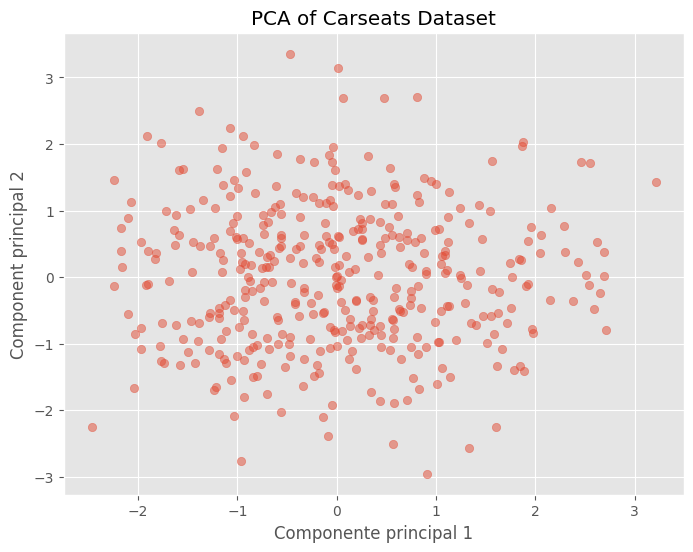

In [ ]:
# Visualizar los componentes principales
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5)
plt.xlabel('Componente principal 1')
plt.ylabel('Component principal 2')
plt.title('PCA of Carseats Dataset')
plt.show()


In [ ]:
#miramos el ratio de variabilidad explicada por cada componente
print("El porcentaje de varianza explicada por cada componente es: ",
      pca.explained_variance_ratio_)

El porcentaje de varianza explicada por cada componente es:  [0.21878279 0.18673577 0.16875669 0.15934438 0.14993343 0.11644696]


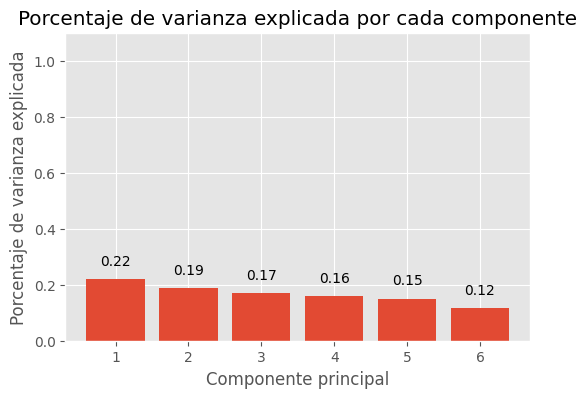

In [ ]:
#lo graficamos:
fig, ax=plt.subplots(nrows=1,ncols=1,figsize=(6,4))#6 filas , 4 columnas
ax.bar(
    x=np.arange(pca.n_components_)+1,
    height=pca.explained_variance_ratio_
)
for x,y in zip(np.arange(len(data.columns))+1,pca.explained_variance_ratio_):
  label=round(y,2)
  ax.annotate(
      label,
      (x,y),
      textcoords="offset points",
      xytext=(0,10),
      ha="center"
  )
  ax.set_xticks(np.arange(pca.n_components_)+1)
  ax.set_ylim(0,1.1)
  ax.set_title("Porcentaje de varianza explicada por cada componente")
  ax.set_xlabel("Componente principal")
  ax.set_ylabel("Porcentaje de varianza explicada")

In [ ]:
#vemos el porcentaje de varianza explicada acumulada
varianza_acumulada=pca.explained_variance_ratio_.cumsum()
print("El porcentaje de varianza explicada acumulada es: ", varianza_acumulada)

El porcentaje de varianza explicada acumulada es:  [0.21878279 0.40551855 0.57427524 0.73361962 0.88355304 1.        ]


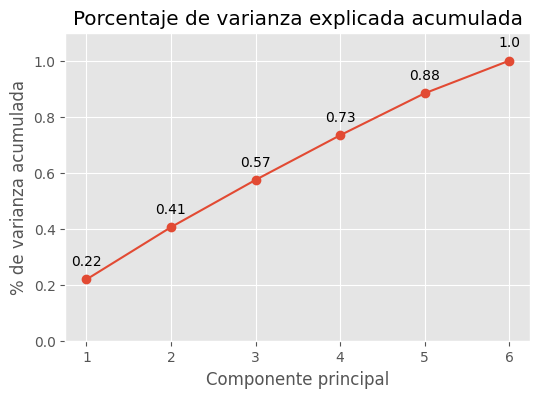

In [ ]:
#lo graficamos:
fig, ax=plt.subplots(nrows=1,ncols=1,figsize=(6,4))
ax.plot(
    np.arange(pca.n_components_) + 1,
    varianza_acumulada,
    marker="o"
)
for x,y in zip(np.arange(pca.n_components_) + 1, varianza_acumulada):
  label=round(y,2)
  ax.annotate(
      label,
      (x,y),
      textcoords="offset points",
      xytext=(0,10),
      ha="center"
  )
  ax.set_ylim(0,1.1)
  ax.set_xticks(np.arange(pca.n_components_) + 1)
  ax.set_title("Porcentaje de varianza explicada acumulada")
  ax.set_xlabel("Componente principal")
  ax.set_ylabel("% de varianza acumulada");

In [ ]:
# Aplicamos el método de PCA para reducir la dimensionalidad
#seleccionamos 4 componentes y le pedimos que haga la transformación
#a partir de los datos escalados

pca = PCA(n_components=4)
pca_features = pca.fit_transform(x_scaled)

In [ ]:
# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2','PC3','PC4'])
pca_df

,PC1,PC2,PC3,PC4
0,0.216348,0.726584,-0.218377,1.239088
1,1.058513,-1.371643,-0.690794,-1.145428
2,0.244060,-0.913468,-0.951392,-1.101174
3,0.744708,-1.054885,0.341071,0.380123
4,0.234639,0.867057,0.587545,-0.511449
...,...,...,...,...
395,1.121102,0.534877,1.318740,1.430435
396,-1.271253,0.462978,-0.113588,-1.793487
397,0.478178,2.694384,-1.417826,0.640322
398,0.378890,-0.800503,0.515726,-0.347409


In [ ]:
#miramos el ratio de variabilidad explicada por cada componente
print("El porcentaje de varianza explicada por cada componente es: ",
      pca.explained_variance_ratio_)

El porcentaje de varianza explicada por cada componente es:  [0.21878279 0.18673577 0.16875669 0.15934438]


In [ ]:
#agregamos los datos de la variable explicada
pca_df['Ventas'] = data["Sales"]
pca_df

,PC1,PC2,PC3,PC4,Ventas
0,0.216348,0.726584,-0.218377,1.239088,9.50
1,1.058513,-1.371643,-0.690794,-1.145428,11.22
2,0.244060,-0.913468,-0.951392,-1.101174,10.06
3,0.744708,-1.054885,0.341071,0.380123,7.40
4,0.234639,0.867057,0.587545,-0.511449,4.15
...,...,...,...,...,...
395,1.121102,0.534877,1.318740,1.430435,12.57
396,-1.271253,0.462978,-0.113588,-1.793487,6.14
397,0.478178,2.694384,-1.417826,0.640322,7.41
398,0.378890,-0.800503,0.515726,-0.347409,5.94


Otro ejemplo - Búsqueda de anomalías financieras

In [ ]:
# Primeros pasos
# Importar librerías necesarias
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D


# Descargar datos financieros reales de múltiples activos
def descargar_datos(tickers, inicio, fin):
    """
    Descarga datos históricos de cierre ajustado para múltiples activos
    """
    datos = yf.download(tickers, start=inicio, end=fin)['Close']
    return datos

# Definir período de tiempo y activos (índices y acciones globales)
tickers = ['^GSPC', 'AAPL', 'GOOGL', 'GLD', 'SLV', 'BTC-USD', 'ETH-USD', 'CVX']
inicio = '2022-01-01'
fin = '2025-12-31'

print("Descargando datos financieros...")
datos = descargar_datos(tickers, inicio, fin)
datos.columns = ['S&P500', 'APPLE', 'GOOGLE', 'GOLD', 'SILVER', 'BITCOIN', 'ETHEREUM', 'CHEVRON']

# Calcular retornos diarios y limpiar datos
retornos = datos.pct_change().dropna()
retornos #visualizamos el Data Frame

Descargando datos financieros...


/tmp/ipykernel_44937/3359001683.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(tickers, start=inicio, end=fin)['Close']
[*********************100%***********************]  8 of 8 completed
/tmp/ipykernel_44937/3359001683.py:32: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = datos.pct_change().dropna()


,S&P500,APPLE,GOOGLE,GOLD,SILVER,BITCOIN,ETHEREUM,CHEVRON
Date,,,,,,,,
2022-01-04,-0.012692,-0.012066,0.018196,0.008687,0.007367,-0.004083,0.006610,-0.000630
2022-01-05,-0.026600,-0.050734,0.006506,-0.064224,-0.003008,-0.045876,-0.015009,-0.019393
2022-01-06,-0.016693,-0.009366,0.008509,-0.037173,-0.012244,-0.000200,-0.023333,-0.000964
2022-01-07,0.000988,-0.037141,0.014360,-0.065878,0.004551,-0.005303,0.005363,-0.004050
2022-01-08,0.000000,0.004236,0.000000,-0.031704,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
2025-12-26,-0.001497,0.000764,-0.003189,0.007634,0.011677,-0.001847,0.090463,-0.000304
2025-12-27,0.000000,0.005736,0.000000,0.007606,0.000000,0.000000,0.000000,0.000000
2025-12-28,0.000000,0.000384,0.000000,0.000193,0.000000,0.000000,0.000000,0.000000


In [ ]:
# Estandarizamos los datos previo a hacer PCA
scaler = StandardScaler()
retornos_std = scaler.fit_transform(retornos)

In [ ]:
# Aplicamos PCA
pca = PCA()  #
componentes = pca.fit_transform(retornos_std)

# Creamos DataFrame con los componentes principales
pca_df = pd.DataFrame(data=componentes, columns=['PC1', 'PC2', 'PC3','PC4','PC5','PC6','PC7','PC8'])

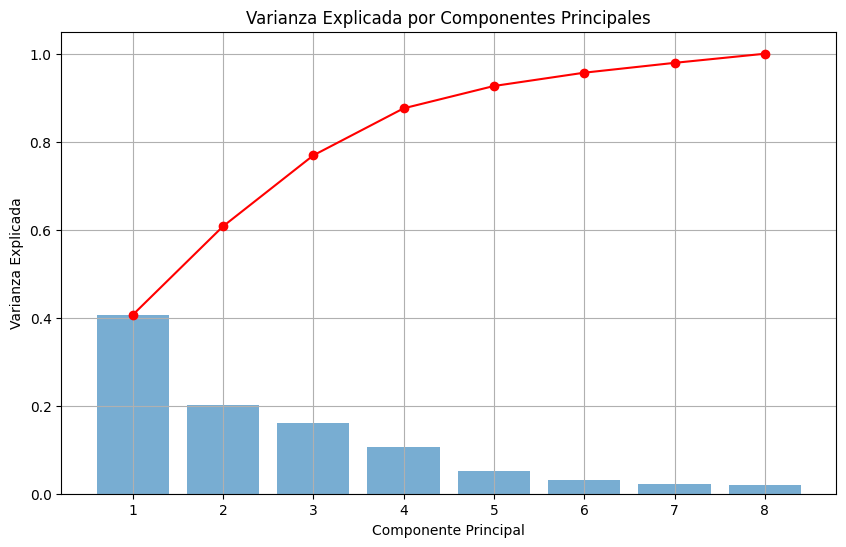

In [ ]:
# Visualizamos la varianza explicada
plt.figure(figsize=(10, 6))
plt.bar(range(1, 9), pca.explained_variance_ratio_, alpha=0.6)
plt.plot(range(1, 9), np.cumsum(pca.explained_variance_ratio_), 'ro-')
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada por Componentes Principales')
plt.xticks(range(1, 9))
plt.grid(True)
plt.show()

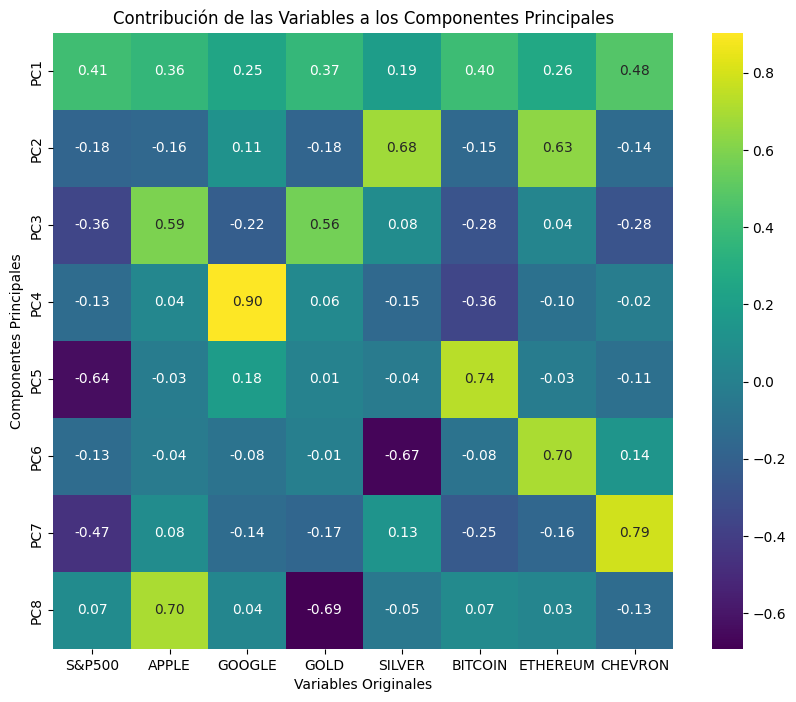

In [ ]:
# Visualizar los "loadings" (contribución de las variables originales a los componentes principales)
plt.figure(figsize=(10, 8))
sns.heatmap(pca.components_,
            cmap='viridis',
            yticklabels=[f'PC{i+1}' for i in range(pca.n_components_)],
            xticklabels=retornos.columns,
            annot=True,
            fmt=".2f")
plt.title('Contribución de las Variables a los Componentes Principales')
plt.xlabel('Variables Originales')
plt.ylabel('Componentes Principales')
plt.show()

In [ ]:
# Mostrar los autovalores
print("\nAutovalores (Varianza explicada por cada componente principal):")
print(pca.explained_variance_)


Autovalores (Varianza explicada por cada componente principal):
[3.25168726 1.61248596 1.29184923 0.85577957 0.4065183  0.24214604
 0.1789938  0.16603435]


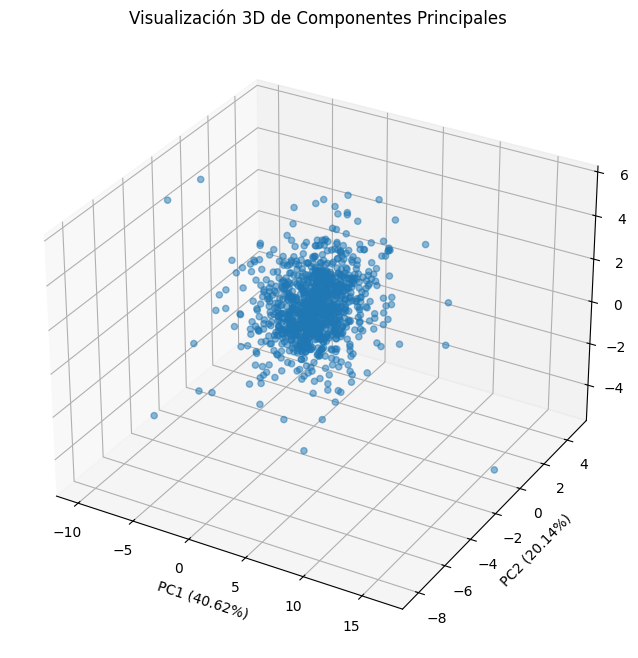

In [ ]:
# Visualización 3D de los componentes principales
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], alpha=0.5)
ax.set_xlabel('PC1 (%.2f%%)' % (pca.explained_variance_ratio_[0]*100))
ax.set_ylabel('PC2 (%.2f%%)' % (pca.explained_variance_ratio_[1]*100))
ax.set_zlabel('PC3 (%.2f%%)' % (pca.explained_variance_ratio_[2]*100))
plt.title('Visualización 3D de Componentes Principales')
plt.show()

Buscamos anomalías

In [ ]:
# Reconstruir los datos a partir de los componentes principales
reconstruidos = pca.inverse_transform(componentes)

# Calcular error de reconstrucción (MSE)
mse = np.mean(np.square(retornos_std - reconstruidos), axis=1)

# Identificar anomalías (umbral = percentil 95)
umbral = np.percentile(mse, 95)
anomalias = mse > umbral

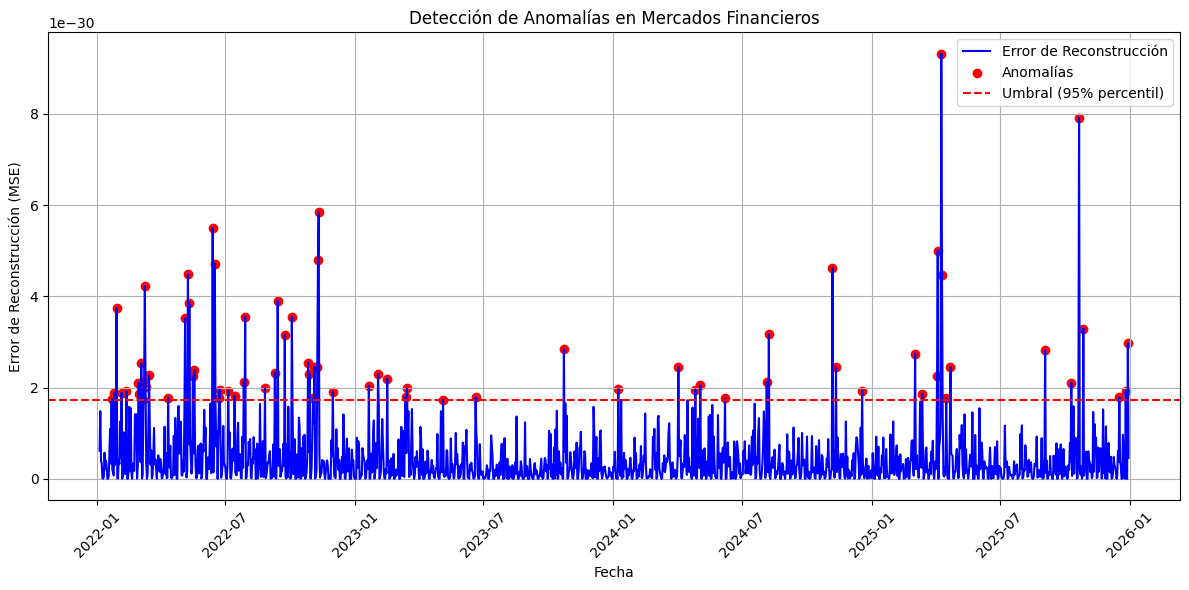

In [ ]:
# Visualizar anomalías
plt.figure(figsize=(12, 6))
plt.plot(retornos.index, mse, 'b-', label='Error de Reconstrucción')
plt.scatter(retornos.index[anomalias], mse[anomalias], color='red', label='Anomalías')
plt.axhline(y=umbral, color='r', linestyle='--', label='Umbral (95% percentil)')
plt.title('Detección de Anomalías en Mercados Financieros')
plt.xlabel('Fecha')
plt.ylabel('Error de Reconstrucción (MSE)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Analizamos fechas con anomalías
anomalias_df = retornos[anomalias]
print("\nFechas con anomalías detectadas:")
print(anomalias_df.index)


Fechas con anomalías detectadas:
DatetimeIndex(['2022-01-21', '2022-01-25', '2022-01-28', '2022-02-04',
               '2022-02-11', '2022-02-28', '2022-03-01', '2022-03-04',
               '2022-03-07', '2022-03-08', '2022-03-09', '2022-03-10',
               '2022-03-15', '2022-04-11', '2022-05-05', '2022-05-09',
               '2022-05-11', '2022-05-16', '2022-05-18', '2022-06-13',
               '2022-06-16', '2022-06-22', '2022-06-23', '2022-07-05',
               '2022-07-14', '2022-07-27', '2022-07-29', '2022-08-26',
               '2022-09-09', '2022-09-13', '2022-09-23', '2022-10-03',
               '2022-10-26', '2022-10-28', '2022-11-02', '2022-11-04',
               '2022-11-08', '2022-11-09', '2022-11-10', '2022-11-30',
               '2023-01-20', '2023-02-02', '2023-02-15', '2023-03-13',
               '2023-03-15', '2023-05-05', '2023-06-20', '2023-10-23',
               '2024-01-08', '2024-04-02', '2024-04-26', '2024-05-03',
               '2024-06-07', '2024-08-05', 

In [ ]:
# Vemos los 5 días con mayores anomalías
top_anomalias = anomalias_df.iloc[np.argsort(-mse[anomalias])[:5]]
print("\nTop 5 días con mayores anomalías:")
print(top_anomalias)


Top 5 días con mayores anomalías:
              S&P500     APPLE    GOOGLE      GOLD    SILVER   BITCOIN  \
Date                                                                     
2025-04-09  0.153288  0.082625  0.066457  0.132754  0.036991  0.096821   
2025-10-21  0.002021 -0.019098 -0.004467 -0.026125 -0.064269 -0.023738   
2022-11-10  0.088975  0.107425  0.018940  0.181149  0.030444  0.075813   
2022-06-13 -0.038285 -0.159747 -0.046009 -0.166504 -0.026412 -0.042901   
2025-04-04 -0.072887  0.008916 -0.082244 -0.000166 -0.023392 -0.033970   

            ETHEREUM   CHEVRON  
Date                            
2025-04-09  0.033898  0.095154  
2025-10-21 -0.082355  0.000033  
2022-11-10  0.031508  0.055434  
2022-06-13 -0.034175 -0.038768  
2025-04-04 -0.062651 -0.059750  


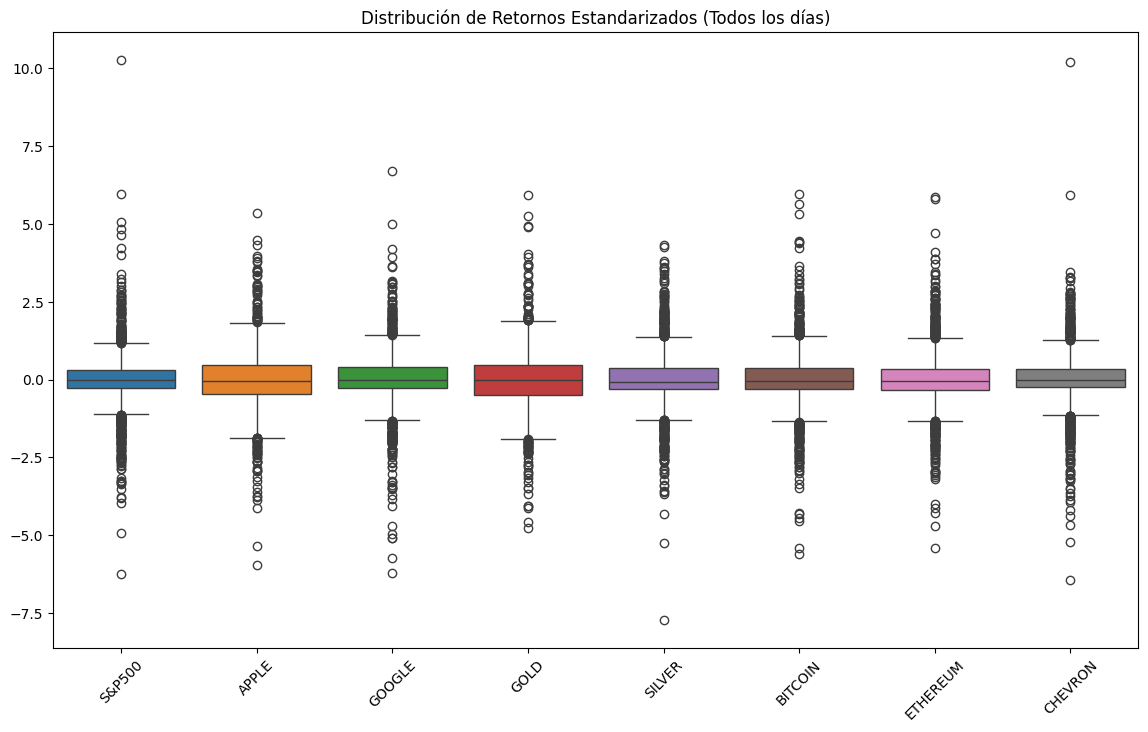

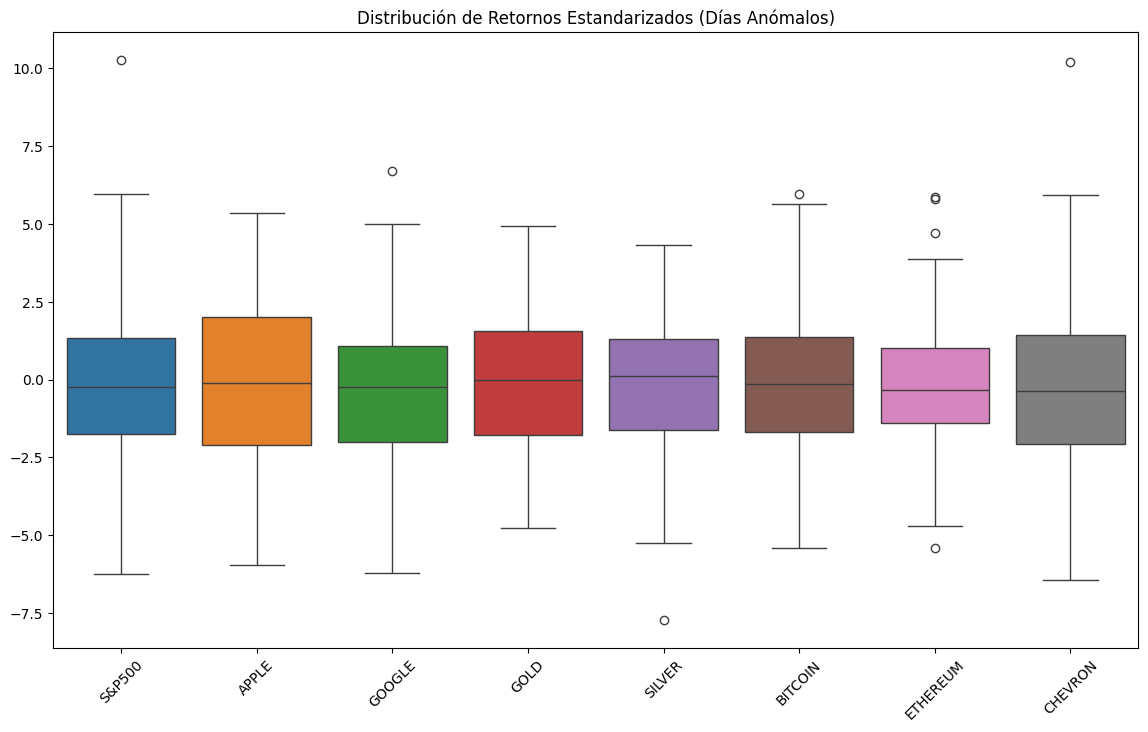

In [ ]:
# Visualizamos comportamiento de los activos en días normales vs anómalos
plt.figure(figsize=(14, 8))
sns.boxplot(data=pd.DataFrame(retornos_std, columns=retornos.columns))
plt.title('Distribución de Retornos Estandarizados (Todos los días)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14, 8))
sns.boxplot(data=pd.DataFrame(retornos_std[anomalias], columns=retornos.columns))
plt.title('Distribución de Retornos Estandarizados (Días Anómalos)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Estandarizamos los datos previo a hacer PCA
scaler = StandardScaler()
retornos_std = scaler.fit_transform(retornos)

In [ ]:
# Aplicamos PCA
pca = PCA(n_components=4)  #
componentes = pca.fit_transform(retornos_std)

# Creamos DataFrame con los componentes principales
pca_df = pd.DataFrame(data=componentes, columns=['PC1', 'PC2', 'PC3','PC4'])

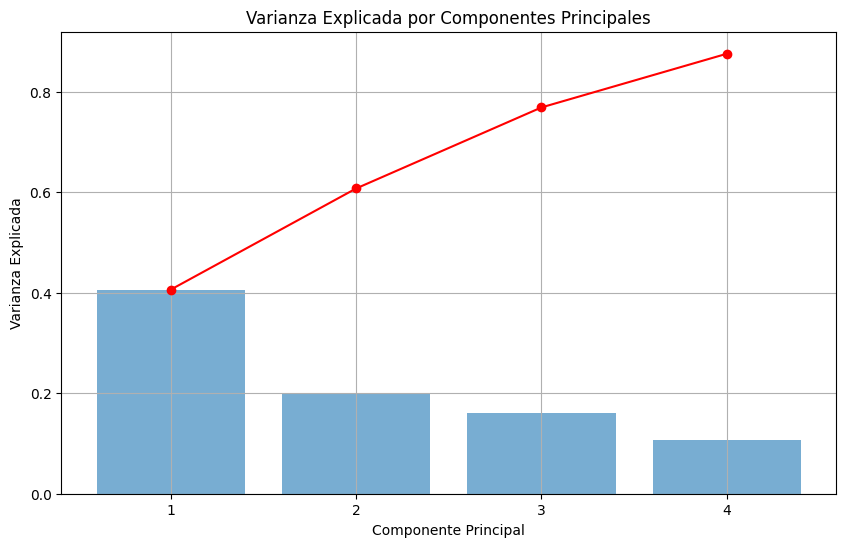

In [ ]:
# Visualizamos la varianza explicada
plt.figure(figsize=(10, 6))
plt.bar(range(1, 5), pca.explained_variance_ratio_, alpha=0.6)
plt.plot(range(1, 5), np.cumsum(pca.explained_variance_ratio_), 'ro-')
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada por Componentes Principales')
plt.xticks(range(1, 5))
plt.grid(True)
plt.show()

In [ ]:
# Reconstruir los datos a partir de los componentes principales
reconstruidos = pca.inverse_transform(componentes)

# Calcular error de reconstrucción (MSE)
mse = np.mean(np.square(retornos_std - reconstruidos), axis=1)

# Identificar anomalías (umbral = percentil 95)
umbral = np.percentile(mse, 95)
anomalias = mse > umbral

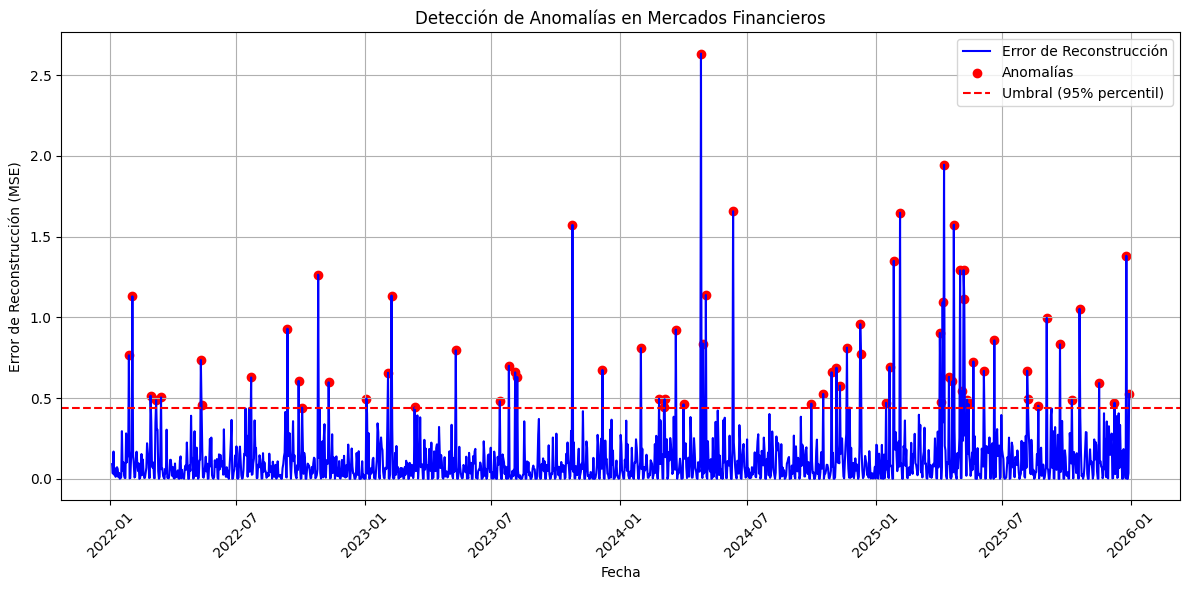

In [ ]:
# Visualizar anomalías
plt.figure(figsize=(12, 6))
plt.plot(retornos.index, mse, 'b-', label='Error de Reconstrucción')
plt.scatter(retornos.index[anomalias], mse[anomalias], color='red', label='Anomalías')
plt.axhline(y=umbral, color='r', linestyle='--', label='Umbral (95% percentil)')
plt.title('Detección de Anomalías en Mercados Financieros')
plt.xlabel('Fecha')
plt.ylabel('Error de Reconstrucción (MSE)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Analizamos fechas con anomalías
anomalias_df = retornos[anomalias]
print("\nFechas con anomalías detectadas:")
print(anomalias_df.index)


Fechas con anomalías detectadas:
DatetimeIndex(['2022-01-28', '2022-02-02', '2022-02-28', '2022-03-08',
               '2022-03-15', '2022-05-11', '2022-05-12', '2022-07-22',
               '2022-09-12', '2022-09-28', '2022-10-03', '2022-10-26',
               '2022-11-10', '2023-01-03', '2023-02-03', '2023-02-08',
               '2023-03-13', '2023-05-11', '2023-07-13', '2023-07-26',
               '2023-08-04', '2023-08-07', '2023-10-25', '2023-12-07',
               '2024-01-31', '2024-02-26', '2024-03-04', '2024-03-05',
               '2024-03-21', '2024-04-01', '2024-04-26', '2024-04-29',
               '2024-05-03', '2024-06-11', '2024-10-01', '2024-10-18',
               '2024-10-30', '2024-11-06', '2024-11-11', '2024-11-21',
               '2024-12-10', '2024-12-11', '2025-01-16', '2025-01-21',
               '2025-01-27', '2025-02-05', '2025-04-03', '2025-04-04',
               '2025-04-07', '2025-04-09', '2025-04-16', '2025-04-21',
               '2025-04-23', '2025-05-02', 

In [ ]:
# Vemos los 5 días con mayores anomalías
top_anomalias = anomalias_df.iloc[np.argsort(-mse[anomalias])[:5]]
print("\nTop 5 días con mayores anomalías:")
print(top_anomalias)


Top 5 días con mayores anomalías:
              S&P500     APPLE    GOOGLE      GOLD    SILVER   BITCOIN  \
Date                                                                     
2024-04-26 -0.003473 -0.011265  0.003691 -0.008346  0.003242  0.102244   
2025-04-09  0.153288  0.082625  0.066457  0.132754  0.036991  0.096821   
2024-06-11  0.072649 -0.031365 -0.001595 -0.045923  0.002857  0.009200   
2025-02-05 -0.001418 -0.012837 -0.001501  0.019279  0.006210 -0.072924   
2025-04-23  0.024332  0.002753 -0.004516  0.022063 -0.023979  0.025616   

            ETHEREUM   CHEVRON  
Date                            
2024-04-26 -0.006784  0.010209  
2025-04-09  0.033898  0.095154  
2024-06-11 -0.015118  0.002710  
2025-02-05  0.004449  0.003909  
2025-04-23  0.035932  0.016661  


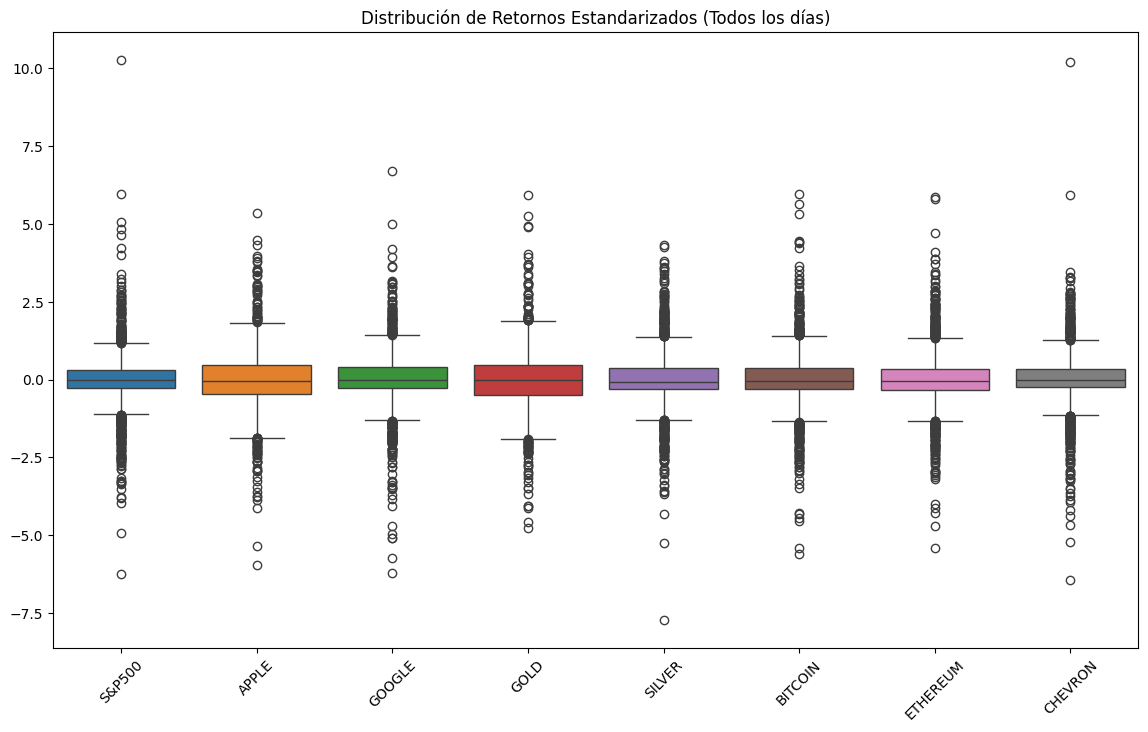

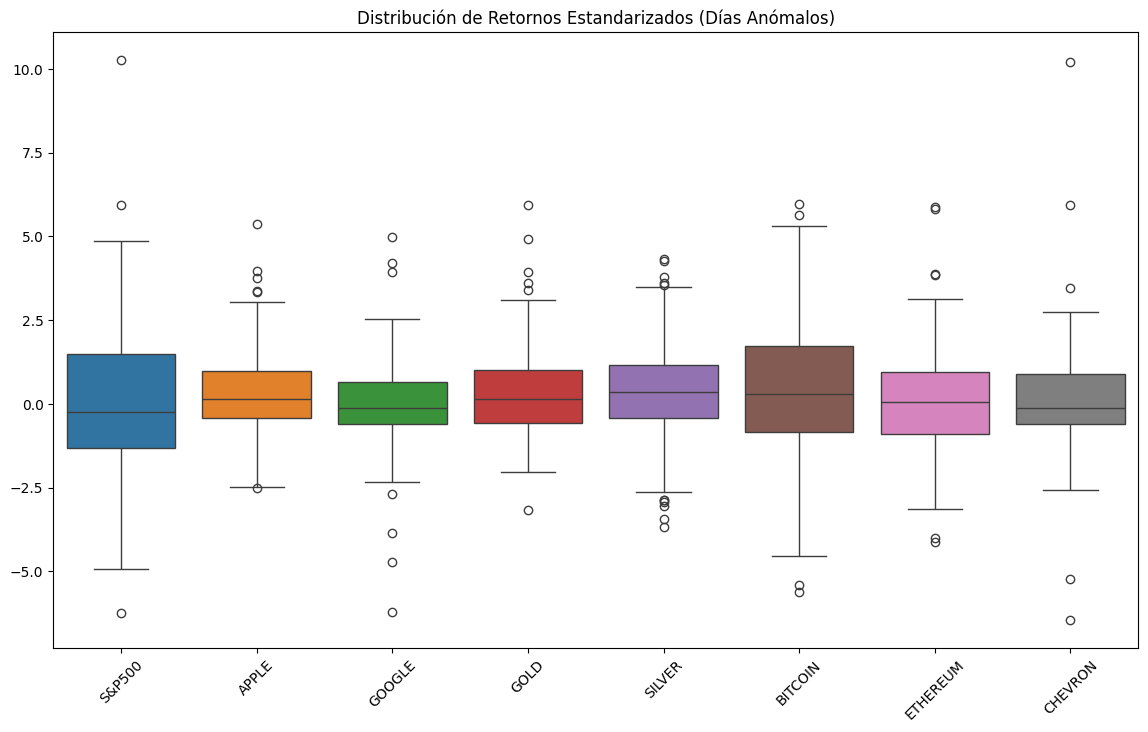

In [ ]:
# Visualizamos comportamiento de los activos en días normales vs anómalos
plt.figure(figsize=(14, 8))
sns.boxplot(data=pd.DataFrame(retornos_std, columns=retornos.columns))
plt.title('Distribución de Retornos Estandarizados (Todos los días)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14, 8))
sns.boxplot(data=pd.DataFrame(retornos_std[anomalias], columns=retornos.columns))
plt.title('Distribución de Retornos Estandarizados (Días Anómalos)')
plt.xticks(rotation=45)
plt.show()

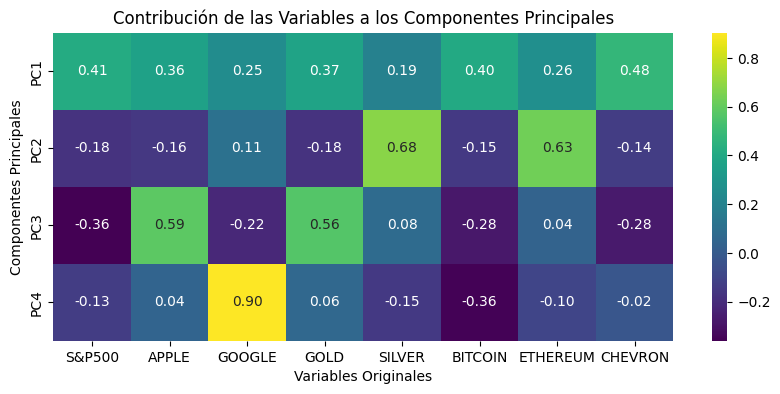

In [ ]:
# Visualizar los "loadings" (contribución de las variables originales a los componentes principales)
plt.figure(figsize=(10, 4))
sns.heatmap(pca.components_,
            cmap='viridis',
            yticklabels=[f'PC{i+1}' for i in range(pca.n_components_)],
            xticklabels=retornos.columns,
            annot=True,
            fmt=".2f")
plt.title('Contribución de las Variables a los Componentes Principales')
plt.xlabel('Variables Originales')
plt.ylabel('Componentes Principales')
plt.show()

Entrenamiento no supervisado

Clustering

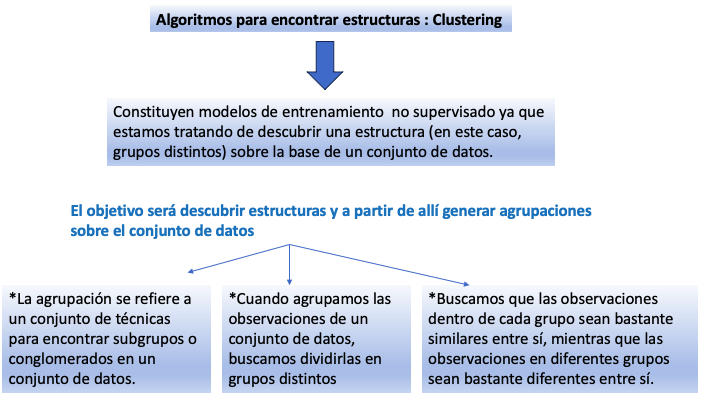

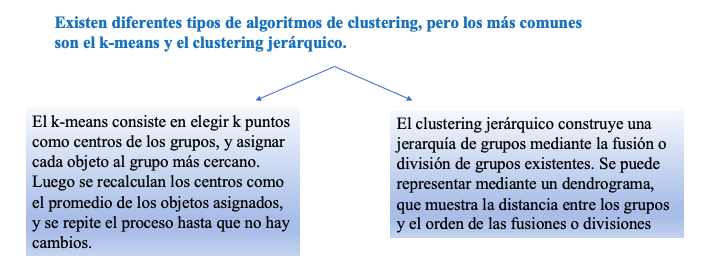

Ejemplo 1

In [ ]:
#Librerías a utilizar
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#usamos el dataset carseats almacenado en el objeto data
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Carseats.csv'
data = pd.read_csv(url)

In [ ]:
# Seleccionamos las variables numéricas
features = ['Price', 'Advertising', 'Income', 'Population', 'Age', 'Education']
X = data[features]

# Estandarizarmos los datos
X_standardized = (X - X.mean()) / X.std()

In [ ]:
# Aplicamos el algoritmo de K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_standardized)


In [ ]:
# Añadimos los clusters al DataFrame original
data['Cluster'] = clusters
data

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Cluster
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,0
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,2
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes,0
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes,1
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes,1
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes,0


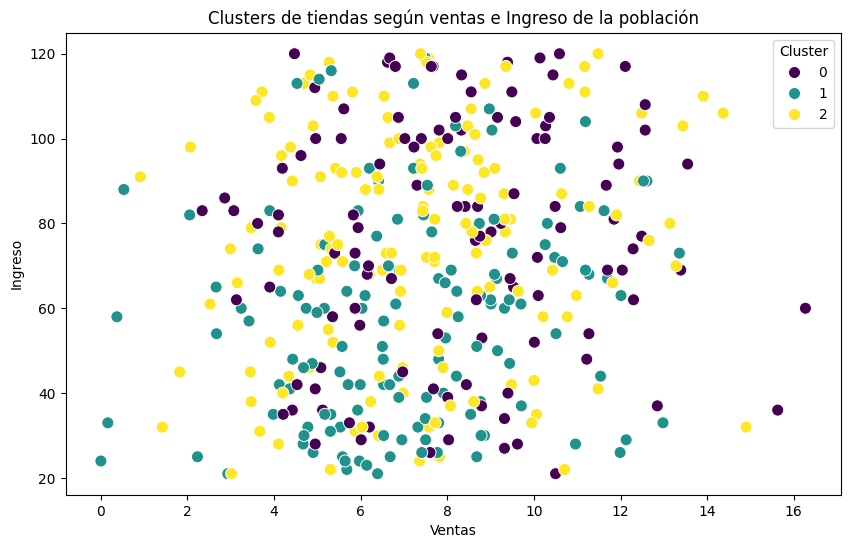

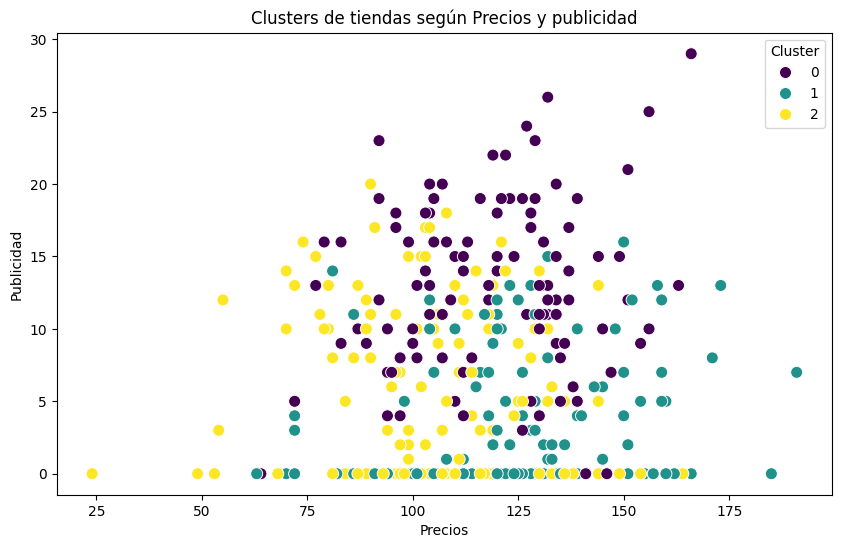

In [ ]:
#gráficos para visualizar los clusters
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sales', y='Income', hue='Cluster', data=data, palette='viridis', s=75)
plt.title('Clusters de tiendas según ventas e Ingreso de la población')
plt.xlabel('Ventas')
plt.ylabel('Ingreso')
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(x='Price', y='Advertising', hue='Cluster', data=data, palette='viridis', s=75)
plt.title('Clusters de tiendas según Precios y publicidad')
plt.xlabel('Precios')
plt.ylabel('Publicidad')
plt.show()



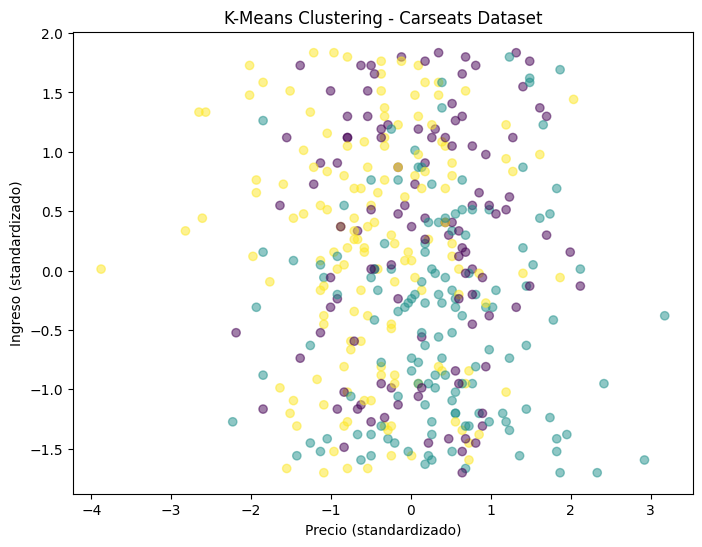

In [ ]:
# Visualizamos los clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_standardized['Price'], X_standardized['Income'], c=clusters, cmap='viridis', alpha=0.5)
plt.xlabel('Precio (standardizado)')
plt.ylabel('Ingreso (standardizado)')
plt.title('K-Means Clustering - Carseats Dataset')
plt.show()


Ejemplo 2

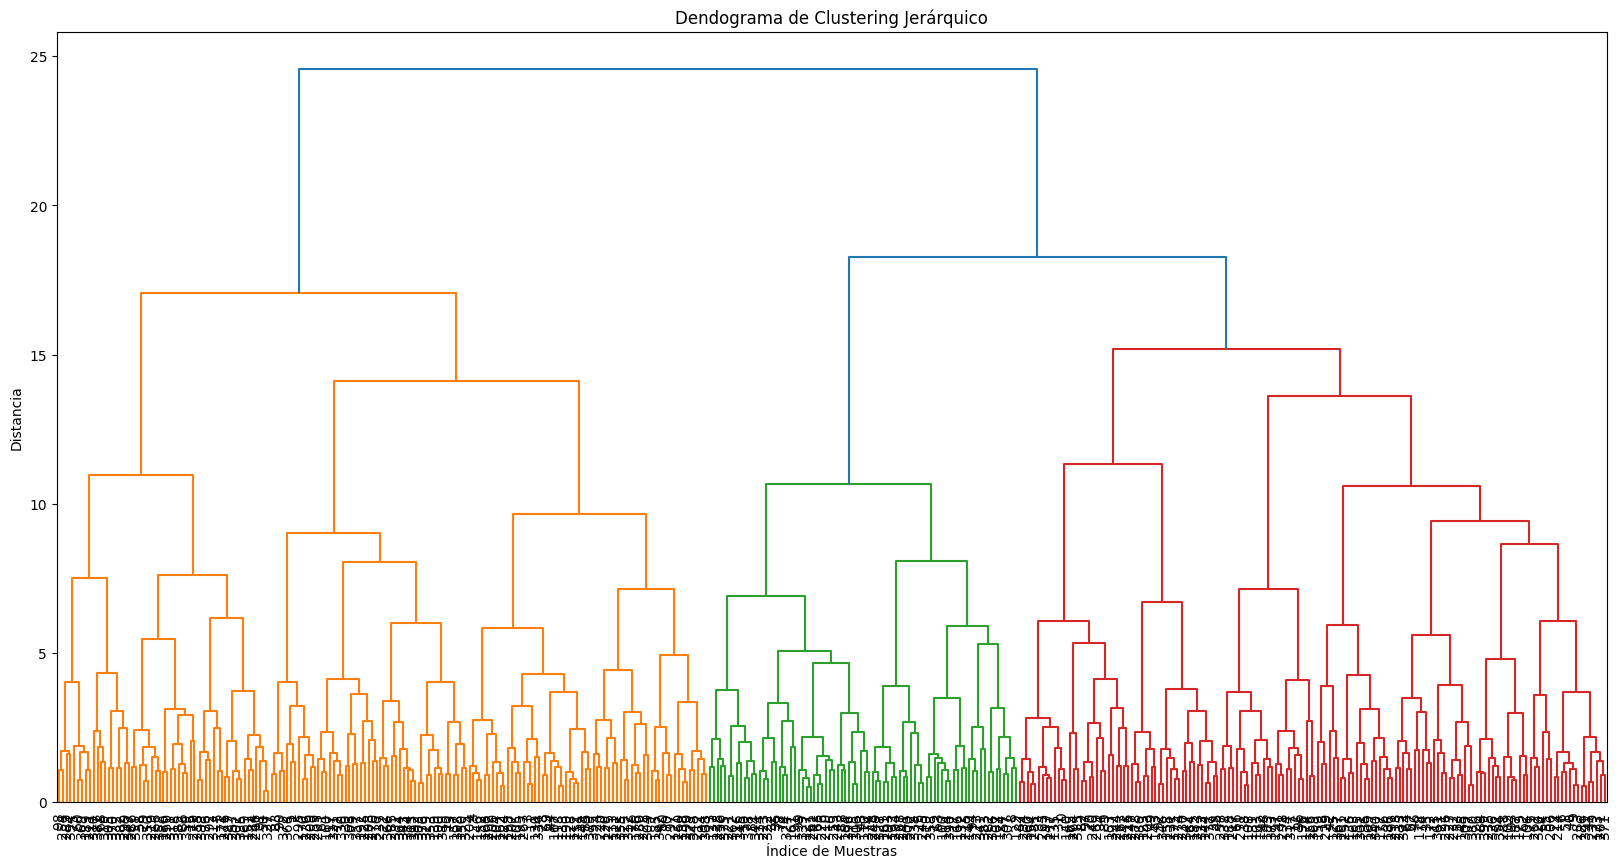

In [ ]:
#clustering jerárquico
#librerías específicas
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

#usamos el archivo data
# Seleccionar las variables numéricas
features = ['Price', 'Advertising', 'Income', 'Population', 'Age', 'Education']
X = data[features]

# Estandarizar los datos
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Aplicar clustering jerárquico
Z = linkage(X_standardized, method='ward')

# Generar el dendograma
plt.figure(figsize=(20, 10))
dendrogram(Z, labels=data.index, leaf_rotation=90, leaf_font_size=10)
plt.title('Dendograma de Clustering Jerárquico')
plt.xlabel('Índice de Muestras')
plt.ylabel('Distancia')
plt.show()


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


# Cortar el dendrograma en 3 clusters
clusters_hierarchical = fcluster(Z, t=3, criterion='maxclust')

# Agregar los clusters al DataFrame original
data['Cluster jerárquico'] = clusters_hierarchical

data

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Cluster,Cluster jerárquico
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1,3
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,0,1
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,2,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0,1
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes,0,1
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes,1,2
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes,1,3
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes,0,1


Otro ejemplo

In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns



# 1. Descargar datos financieros
def descargar_datos(tickers, inicio, fin):
    """Descarga datos históricos de cierre ajustado para múltiples activos"""
    datos = yf.download(tickers, start=inicio, end=fin)['Close']
    return datos

# Definir conjunto de activos diversificados
tickers = [
    'AAPL', 'MSFT', 'GOOGL',  # Tech
    'JPM', 'BAC', 'GS',       # Bancos
    'XOM', 'CVX',             # Energía
    'WMT', 'AMZN',            # Retail
    'GLD', 'SLV',             # Metales
    'TLT', 'IEF',             # Bonos
    '^GSPC', '^IXIC',         # Índices
    'BTC-USD', 'ETH-USD'      # Cripto
]

inicio = '2020-01-01'
fin = '2023-12-31'

print("Descargando datos financieros...")
datos = descargar_datos(tickers, inicio, fin)
datos

/tmp/ipython-input-1872822598.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(tickers, start=inicio, end=fin)['Close']
[                       0%                       ]

Descargando datos financieros...


[*********************100%***********************]  18 of 18 completed


Ticker,AAPL,AMZN,BAC,BTC-USD,CVX,ETH-USD,GLD,GOOGL,GS,IEF,JPM,MSFT,SLV,TLT,WMT,XOM,^GSPC,^IXIC
Date,,,,,,,,,,,,,,,,,,
2020-01-01,NaN,NaN,NaN,7200.174316,NaN,130.802002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,72.620842,94.900497,31.092316,6985.470215,95.001541,127.410179,143.949997,68.026024,205.282974,98.070427,120.154732,153.042267,16.809999,118.028107,36.593369,54.634792,3257.850098,9092.190430
2020-01-03,71.914833,93.748497,30.446728,7344.884277,94.672966,134.171707,145.860001,67.670151,202.882477,98.725830,118.569092,151.136658,16.840000,119.845810,36.270329,54.195541,3234.850098,9020.769531
2020-01-04,NaN,NaN,NaN,7410.656738,NaN,135.069366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-05,NaN,NaN,NaN,7411.317383,NaN,136.276779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-26,191.646545,153.410004,32.620430,42520.402344,142.773285,2231.465332,191.720001,140.676331,368.907257,91.157814,161.836380,370.454865,22.200001,92.854599,51.254135,97.001740,4774.750000,15074.570312
2023-12-27,191.745819,153.339996,32.601158,43442.855469,142.304901,2378.739990,192.589996,139.533173,371.681702,91.868156,162.807068,369.871460,22.230000,94.499954,51.735840,96.545883,4781.580078,15099.179688
2023-12-28,192.172699,153.380005,32.639698,42627.855469,140.300201,2347.566162,191.470001,139.393997,373.547455,91.517715,163.672058,371.067932,21.990000,93.813606,51.634262,95.149841,4783.350098,15095.139648


In [ ]:
# 2. Preprocesamiento de datos
# Calcular retornos anualizados y volatilidad
retornos = np.log(datos/datos.shift(1)).dropna()
retorno_anual = retornos.mean() * 252
volatilidad_anual = retornos.std() * np.sqrt(252)

# Ratio Sharpe (asumiendo rf=0)
sharpe_ratio = retorno_anual / volatilidad_anual

# Matriz de correlación
correlaciones = retornos.corr()

# Crear DataFrame para clustering
df_cluster = pd.DataFrame({
    'Retorno': retorno_anual,
    'Volatilidad': volatilidad_anual,
    'Sharpe': sharpe_ratio
})
df_cluster #Visualizamos el Data Frame

,Retorno,Volatilidad,Sharpe
Ticker,,,
AAPL,0.208845,0.326066,0.640500
AMZN,0.069686,0.384670,0.181157
BAC,0.046312,0.363462,0.127418
BTC-USD,0.435846,0.618256,0.704960
CVX,0.090462,0.371720,0.243361
ETH-USD,0.527188,0.793042,0.664767
GLD,0.102422,0.156498,0.654463
GOOGL,0.224312,0.337354,0.664918
GS,0.115625,0.341137,0.338939


In [ ]:
# Estandarizar los datos
scaler = StandardScaler()
df_std = scaler.fit_transform(df_cluster)

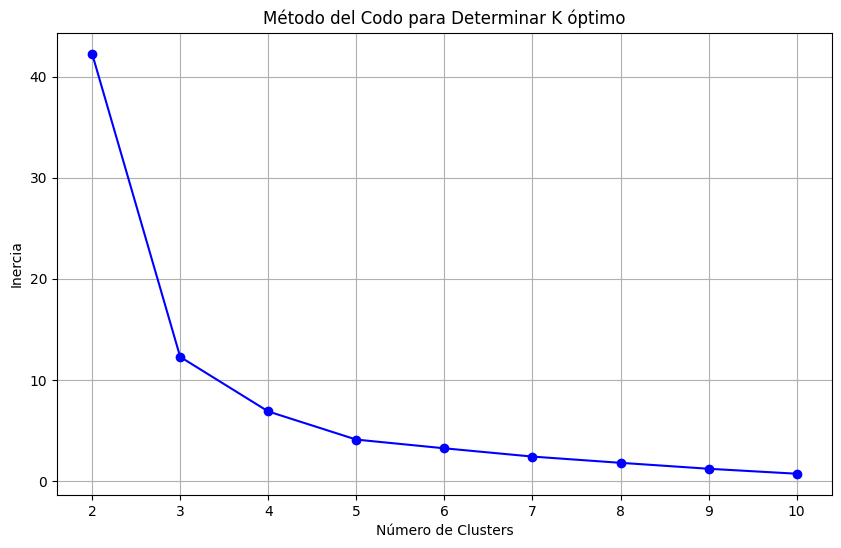

In [ ]:
# 3. Determinar número óptimo de clusters
# Método del codo
inercia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_std)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inercia, 'bo-')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo para Determinar K óptimo')
plt.grid(True)
plt.show()

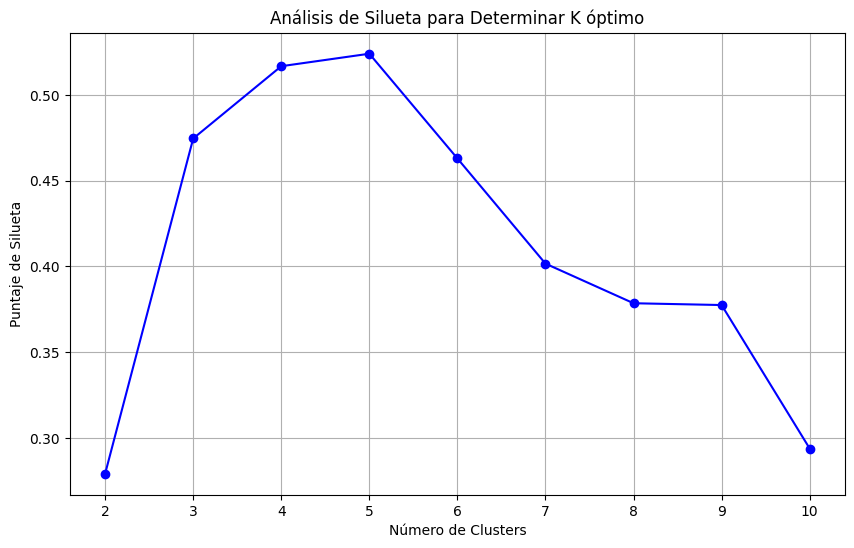

In [ ]:
# Método de la silueta
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    preds = kmeans.fit_predict(df_std)
    score = silhouette_score(df_std, preds)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, 'bo-')
plt.xlabel('Número de Clusters')
plt.ylabel('Puntaje de Silueta')
plt.title('Análisis de Silueta para Determinar K óptimo')
plt.grid(True)
plt.show()

In [ ]:
# 4. Aplicar K-Means (elegir k basado en gráficos anteriores)
k = 4  # Ajustar según análisis previo
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(df_std)

# Añadir clusters al DataFrame
df_cluster['Cluster'] = clusters
df_cluster

,Retorno,Volatilidad,Sharpe,Cluster
Ticker,,,,
AAPL,0.208845,0.326066,0.640500,3
AMZN,0.069686,0.384670,0.181157,1
BAC,0.046312,0.363462,0.127418,1
BTC-USD,0.435846,0.618256,0.704960,2
CVX,0.090462,0.371720,0.243361,1
ETH-USD,0.527188,0.793042,0.664767,2
GLD,0.102422,0.156498,0.654463,0
GOOGL,0.224312,0.337354,0.664918,3
GS,0.115625,0.341137,0.338939,1


/tmp/ipython-input-3683116379.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (df_cluster['Volatilidad'][i], df_cluster['Retorno'][i]),


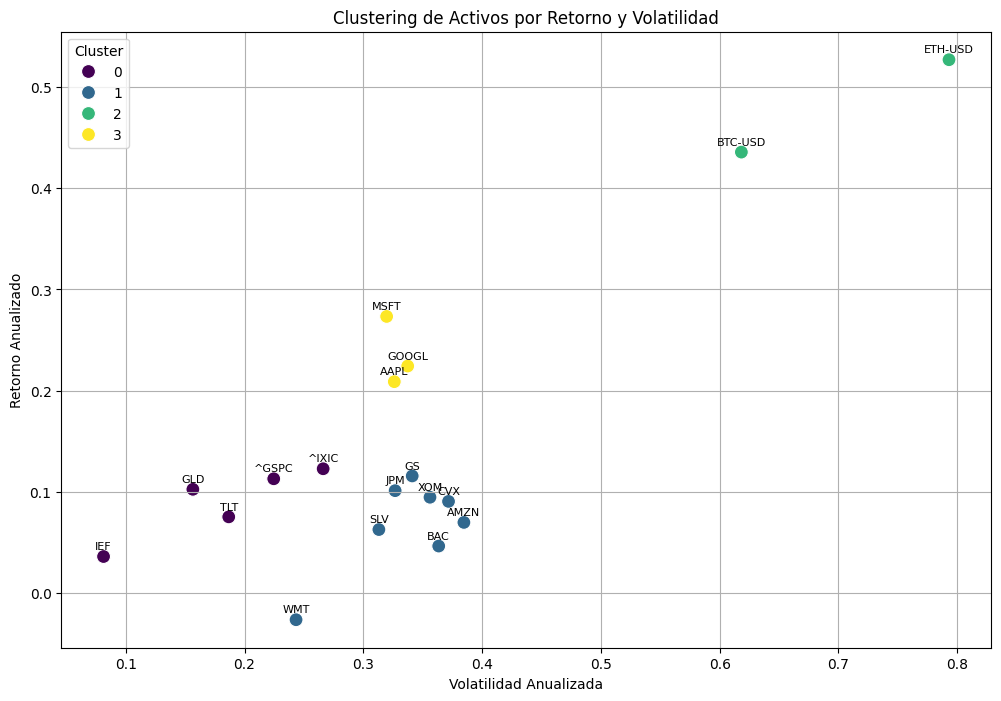

In [ ]:
# 5. Visualización de clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_cluster, x='Volatilidad', y='Retorno',
                hue='Cluster', palette='viridis', s=100)
plt.title('Clustering de Activos por Retorno y Volatilidad')
plt.xlabel('Volatilidad Anualizada')
plt.ylabel('Retorno Anualizado')
plt.grid(True)

# Etiquetar puntos
for i, txt in enumerate(df_cluster.index):
    plt.annotate(txt, (df_cluster['Volatilidad'][i], df_cluster['Retorno'][i]),
                 textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

plt.show()

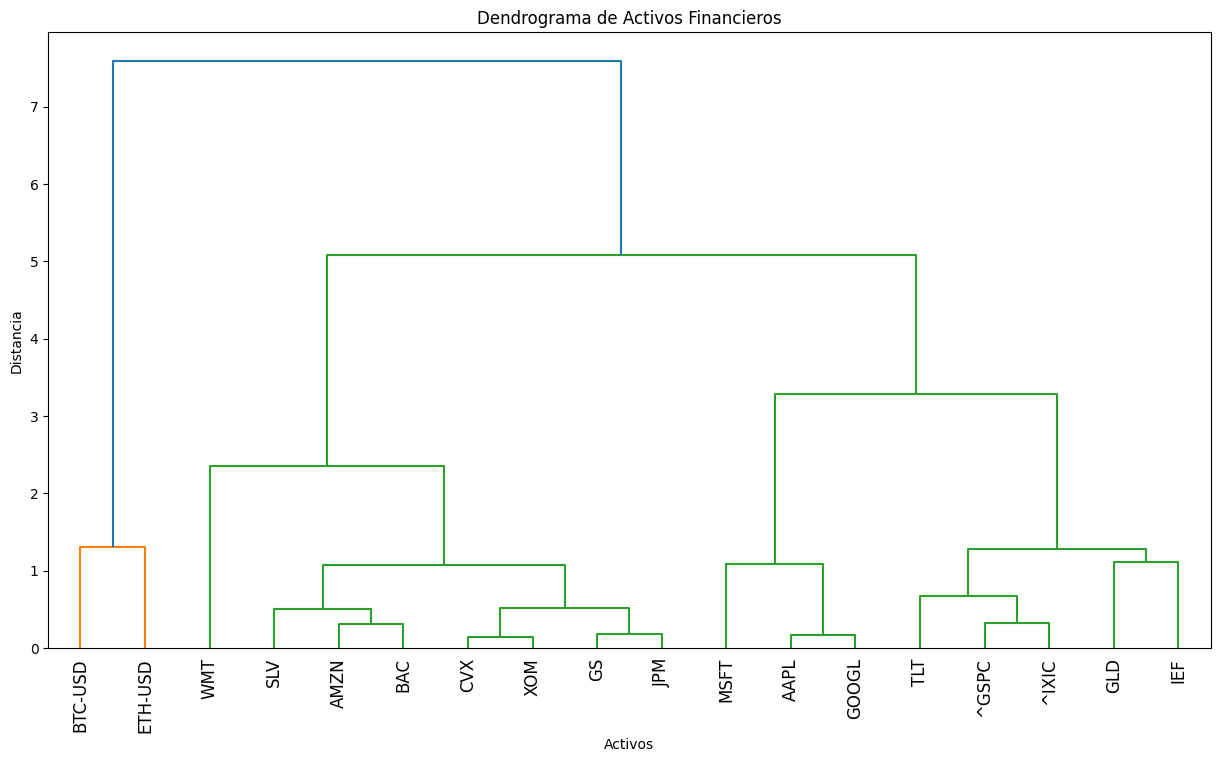

In [ ]:
# 6. Análisis jerárquico
plt.figure(figsize=(15, 8))
linkage_matrix = linkage(df_std, method='ward')
dendrogram(linkage_matrix, labels=df_cluster.index, leaf_rotation=90)
plt.title('Dendrograma de Activos Financieros')
plt.xlabel('Activos')
plt.ylabel('Distancia')
plt.show()

In [ ]:
# 7. Clustering jerárquico
hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
df_cluster['Cluster_HC'] = hc.fit_predict(df_std)

In [ ]:
# 8. Análisis por cluster
print("\nCaracterísticas promedio por cluster (K-Means):")
print(df_cluster.groupby('Cluster').mean())

print("\nActivos por cluster (K-Means):")
for c in range(k):
    print(f"\nCluster {c}:")
    print(df_cluster[df_cluster['Cluster'] == c].index.tolist())



Características promedio por cluster (K-Means):
          Retorno  Volatilidad    Sharpe  Cluster_HC
Cluster                                             
0        0.089818     0.183047  0.492564         2.0
1        0.069225     0.337540  0.194585         0.0
2        0.481517     0.705649  0.684863         1.0
3        0.235504     0.327680  0.720221         3.0

Activos por cluster (K-Means):

Cluster 0:
['GLD', 'IEF', 'TLT', '^GSPC', '^IXIC']

Cluster 1:
['AMZN', 'BAC', 'CVX', 'GS', 'JPM', 'SLV', 'WMT', 'XOM']

Cluster 2:
['BTC-USD', 'ETH-USD']

Cluster 3:
['AAPL', 'GOOGL', 'MSFT']


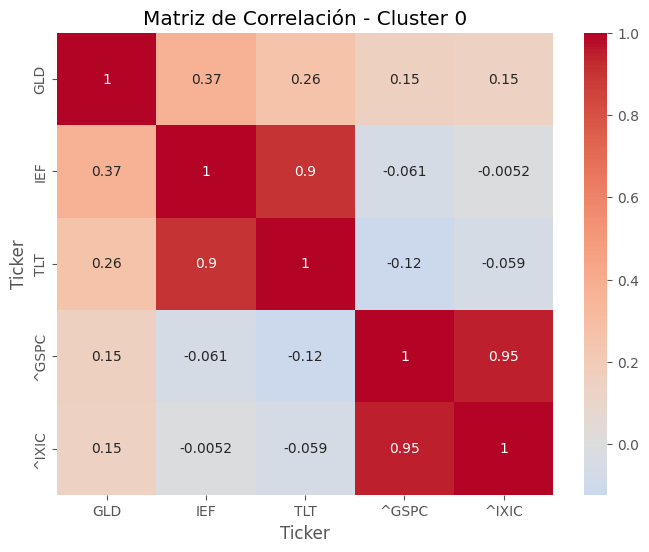

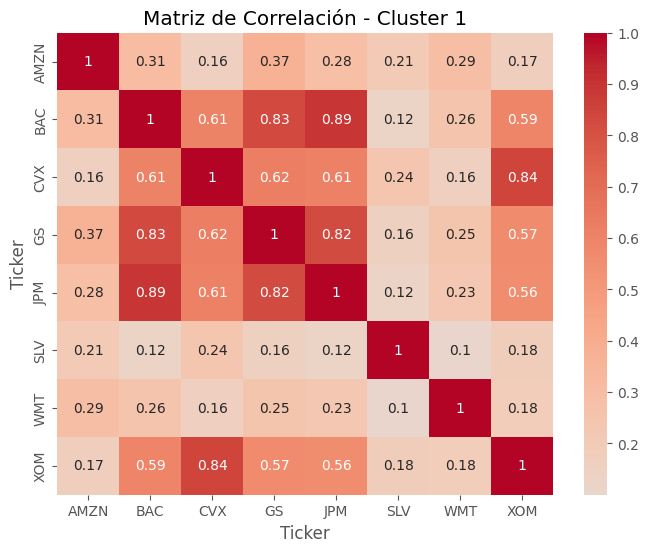

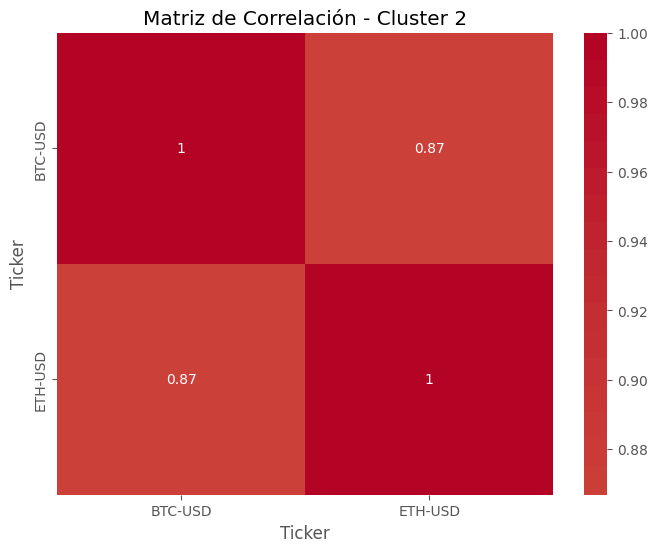

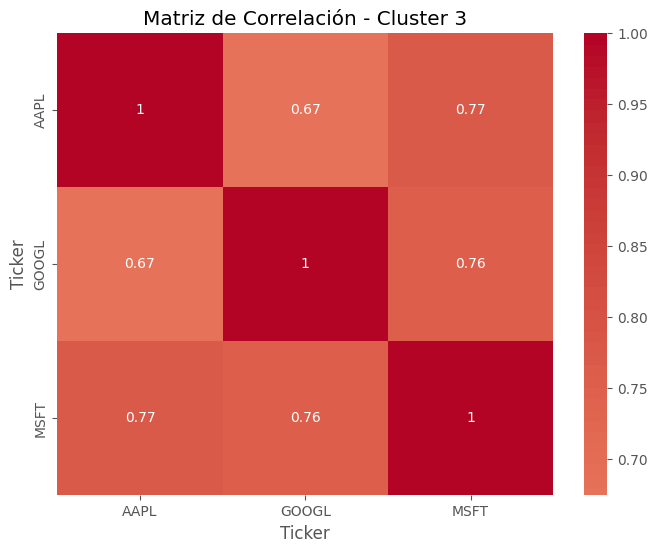

In [ ]:
# 9. Heatmap de correlaciones intra-cluster
for c in range(k):
    activos_cluster = df_cluster[df_cluster['Cluster'] == c].index
    if len(activos_cluster) > 1:
        plt.figure(figsize=(8, 6))
        sns.heatmap(correlaciones.loc[activos_cluster, activos_cluster],
                    annot=True, cmap='coolwarm', center=0)
        plt.title(f'Matriz de Correlación - Cluster {c}')
        plt.show()

/tmp/ipython-input-74-1785642471.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(df_cluster['Volatilidad'][i],
/tmp/ipython-input-74-1785642471.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_cluster['Retorno'][i],
/tmp/ipython-input-74-1785642471.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_cluster['Sharpe'][i],


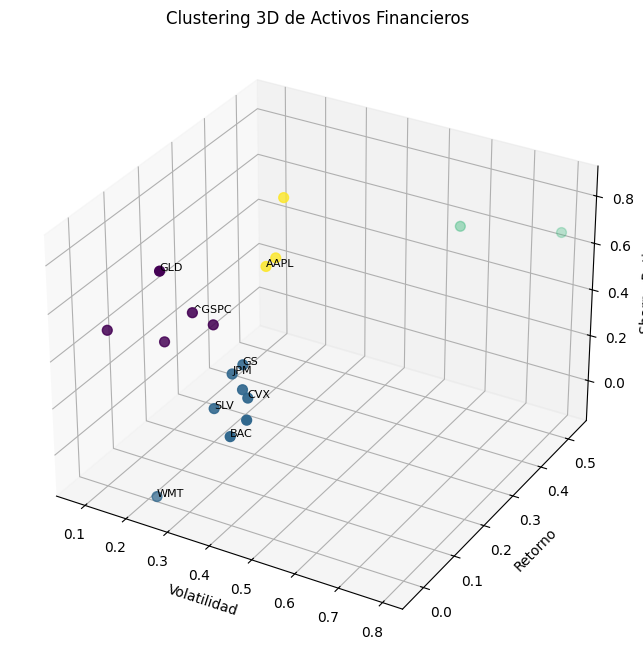

In [ ]:
# 10. Visualización 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df_cluster['Volatilidad'],
                     df_cluster['Retorno'],
                     df_cluster['Sharpe'],
                     c=df_cluster['Cluster'],
                     cmap='viridis', s=50)

ax.set_xlabel('Volatilidad')
ax.set_ylabel('Retorno')
ax.set_zlabel('Sharpe Ratio')
plt.title('Clustering 3D de Activos Financieros')

# Etiquetar algunos puntos
for i, txt in enumerate(df_cluster.index):
    if i % 2 == 0:  # Etiquetar solo algunos para mayor claridad
        ax.text(df_cluster['Volatilidad'][i],
                df_cluster['Retorno'][i],
                df_cluster['Sharpe'][i],
                txt, fontsize=8)

plt.show()